# V10 corrigée — comparaison V9 best vs V10 game-level

Cette version corrige le protocole expérimental :

- comparaison sur `N = [3, 5, 10, 30]` pour chaque cadence ;
- split **par joueur stratifié par Elo** commun à V9 et V10 ;
- exclusion de `game_month` et des colonnes temporelles non comportementales ;
- V10 entraîné avec exactement `N` parties par joueur train pour chaque expérience ;
- pondération game-level `1 / nb_parties_du_joueur` ;
- V9 embeddings réentraînés par seed par défaut, pour mesurer aussi une partie de la variance neuronale ;
- analyse par buckets Elo pour détecter la régression vers la moyenne ;
- V10 reste une expérience d’agrégation tardive/interprétabilité, comparée à la vraie baseline V9 best.


# V10 — Game-level hierarchical model vs meilleure baseline V9

Ce notebook corrige la comparaison : **V10 n’est plus comparée à V8 seulement**, mais à la meilleure approche V9 retenue après les expériences précédentes.

Choix V9 utilisés directement, sans refaire toute la grille :

- **Bullet** : `N=5`, `V8 + embedding mean + LightGBM`
- **Blitz** : `N=10`, `V8 + embedding mean + LightGBM`
- **Rapid** : `N=10`, `V8 + embedding attention + LightGBM`

Objectif V10 : tester une approche hiérarchique au niveau partie :

```text
Chaque partie → Elo local estimé → agrégation des Elo locaux → Elo joueur
```

On compare donc :

```text
V9 best: features joueur V8 + embedding DeepSets + LightGBM
vs
V10: prédictions game-level + agrégation mean/median/trimmed/weighted
```

Puis on analyse aussi l’incertitude via la dispersion des prédictions game-level.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [3]:
# Optionnel : montage Google Drive si vous êtes sur Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Pas dans Google Colab : montage Drive ignoré.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ============================================================
# 0. Imports & configuration V10 corrigée
# ============================================================

import os, sys, random, warnings
from pathlib import Path
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ LightGBM non installé. Installez-le avec: pip install lightgbm")

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠️ PyTorch non installé. Installez-le avec: pip install torch")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
DEVICE = 'cuda' if TORCH_AVAILABLE and torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_STATE)

# ============================================================
# Chemins : adaptez BASE_DIR si nécessaire
# ============================================================
IN_COLAB = 'google.colab' in sys.modules
BASE_DIR = Path('/content/drive/MyDrive/Data_Pmind_700-30') if IN_COLAB else Path(r'G:\Mon Drive\Data_Pmind_700-30')

CADENCES = ['bullet', 'blitz', 'rapid']
CADENCE_DATA_DIRS = {c: BASE_DIR / c for c in CADENCES}

# Vraie comparaison faible-N + référence haute.
N_VALUES = [3, 5, 10, 30]
MAX_N = 30

# Seeds : 5 par défaut pour une conclusion plus stable.
V10_VS_V9_SEEDS = [0, 1, 2, 3, 4]

# Si True : réentraîne le DeepSets/attention V9 pour chaque seed.
# Plus rigoureux, mais plus long. Si vous voulez aller vite, mettez False.
RETRAIN_V9_NEURAL_PER_SEED = True

# Entraînement neural V9 : réglages modestes.
BATCH_SIZE = 64
EPOCHS = 80
PATIENCE = 12
LR = 1e-3
WEIGHT_DECAY = 1e-4
EMB_DIM = 48
HIDDEN_DIM = 96
DROPOUT = 0.20

FAST_DEBUG = False
DEBUG_MAX_PLAYERS_PER_CADENCE = 180

# Seuils V8 repris de vos notebooks.
EVAL_CAP = 900
LOSS_CAP = 600
THRESHOLD_WIN = 150
THRESHOLD_LOSE = -150
LOW_CLOCK_RATIO = 0.20

print('N_VALUES =', N_VALUES)
print('Seeds =', V10_VS_V9_SEEDS)
print('RETRAIN_V9_NEURAL_PER_SEED =', RETRAIN_V9_NEURAL_PER_SEED)


Device: cpu
N_VALUES = [3, 5, 10, 30]
Seeds = [0, 1, 2, 3, 4]
RETRAIN_V9_NEURAL_PER_SEED = True


## 1. Fonctions V8 reprises du notebook V9/V8

In [5]:
def _read_csv_if_exists(path: Path) -> Optional[pd.DataFrame]:
    """Lit un CSV s'il existe, sinon retourne None."""
    if path.exists():
        return pd.read_csv(path)
    return None


def _first_existing_column(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _build_games_from_available(
    cadence: str,
    moves_cad: pd.DataFrame,
    summary_cad: Optional[pd.DataFrame],
    players_cad: pd.DataFrame,
) -> pd.DataFrame:
    """
    Fallback pour une cadence sans fichier games.csv.
    On reconstruit uniquement la table game-level minimale attendue par le notebook,
    à partir de summary.csv puis moves.csv si les colonnes existent.
    """
    required_cols = [
        'game_id', 'target_name', 'speed', 'time_control', 'target_elo',
        'target_result', 'target_score', 'opening_eco', 'opening_ply',
        'ply_count', 'target_color', 'date_utc'
    ]

    sources = [df for df in [summary_cad, moves_cad] if df is not None and 'game_id' in df.columns]
    if not sources:
        raise FileNotFoundError(
            f"{cadence}: games.csv absent et impossible de reconstruire le game-level "
            "car aucun game_id n'a été trouvé dans summary.csv ou moves.csv."
        )

    base = sources[0].copy()
    if base['game_id'].duplicated().any():
        # Une ligne par partie ; first() suffit pour les métadonnées constantes.
        base = base.groupby('game_id', as_index=False).first()

    games_cad = pd.DataFrame({'game_id': base['game_id']})

    column_map = {
        'target_name':   ['target_name', 'username', 'player', 'target_username'],
        'time_control':  ['time_control', 'tc', 'clock'],
        'target_elo':    ['target_elo', 'elo', 'player_elo'],
        'target_result': ['target_result', 'result'],
        'target_score':  ['target_score', 'score'],
        'opening_eco':   ['opening_eco', 'eco'],
        'opening_ply':   ['opening_ply'],
        'ply_count':     ['ply_count', 'plies', 'num_plies'],
        'target_color':  ['target_color', 'player_color', 'color'],
        'date_utc':      ['date_utc', 'created_at', 'date'],
    }

    for out_col, candidates in column_map.items():
        found = _first_existing_column(base, candidates)
        games_cad[out_col] = base[found] if found is not None else np.nan

    # Si ply_count n'existe pas côté summary, le reconstruire depuis moves.
    if games_cad['ply_count'].isna().all() and 'ply' in moves_cad.columns:
        ply_count = moves_cad.groupby('game_id')['ply'].max().add(1).rename('ply_count_rebuilt')
        games_cad = games_cad.merge(ply_count, on='game_id', how='left')
        games_cad['ply_count'] = games_cad['ply_count_rebuilt']
        games_cad = games_cad.drop(columns=['ply_count_rebuilt'])

    games_cad['speed'] = cadence

    # Valeurs par défaut non analytiques, uniquement pour garder le pipeline inchangé.
    default_tc = {'bullet': '60+0', 'blitz': '180+0', 'rapid': '600+0'}
    games_cad['time_control'] = games_cad['time_control'].fillna(default_tc.get(cadence, ''))
    games_cad['opening_eco'] = games_cad['opening_eco'].fillna('?')
    games_cad['opening_ply'] = pd.to_numeric(games_cad['opening_ply'], errors='coerce')
    games_cad['ply_count'] = pd.to_numeric(games_cad['ply_count'], errors='coerce')
    games_cad['target_score'] = pd.to_numeric(games_cad['target_score'], errors='coerce')
    games_cad['target_elo'] = pd.to_numeric(games_cad['target_elo'], errors='coerce')

    missing_core = [c for c in ['target_name'] if games_cad[c].isna().all()]
    if missing_core:
        raise ValueError(
            f"{cadence}: games.csv absent et colonne(s) impossible(s) à reconstruire : {missing_core}. "
            "Ajoute ces colonnes dans summary.csv ou fournis games.csv."
        )

    return games_cad[required_cols]


def _force_cadence(df: pd.DataFrame, cadence: str) -> pd.DataFrame:
    df = df.copy()
    df['speed'] = cadence
    return df


def load_cadence_data(cadence_dirs: dict[str, Path]):
    """Charge bullet/blitz/rapid depuis des dossiers séparés et concatène les tables."""
    all_moves, all_games, all_summary, all_players = [], [], [], []

    for cadence in CADENCES:
        data_dir = cadence_dirs[cadence]
        moves_path   = data_dir / 'moves.csv'
        games_path   = data_dir / 'games.csv'
        summary_path = data_dir / 'summary.csv'
        players_path = data_dir / 'players.csv'

        moves_cad = _read_csv_if_exists(moves_path)
        summary_cad = _read_csv_if_exists(summary_path)
        players_cad = _read_csv_if_exists(players_path)

        if moves_cad is None:
            raise FileNotFoundError(f"{cadence}: fichier introuvable -> {moves_path}")
        if players_cad is None:
            raise FileNotFoundError(f"{cadence}: fichier introuvable -> {players_path}")
        if summary_cad is None:
            summary_cad = pd.DataFrame()

        games_cad = _read_csv_if_exists(games_path)
        if games_cad is None:
            print(f"⚠ {cadence}: games.csv absent — reconstruction minimale depuis summary/moves")
            games_cad = _build_games_from_available(cadence, moves_cad, summary_cad, players_cad)

        moves_cad   = _force_cadence(moves_cad, cadence)
        games_cad   = _force_cadence(games_cad, cadence)
        summary_cad = _force_cadence(summary_cad, cadence) if len(summary_cad) else summary_cad
        players_cad = _force_cadence(players_cad, cadence)

        all_moves.append(moves_cad)
        all_games.append(games_cad)
        all_summary.append(summary_cad)
        all_players.append(players_cad)

        print(f"\n[{cadence.upper()}] {data_dir}")
        print(f"  moves   : {moves_cad.shape[0]:>8,} × {moves_cad.shape[1]}")
        print(f"  games   : {games_cad.shape[0]:>8,} × {games_cad.shape[1]}")
        print(f"  players : {players_cad.shape[0]:>8,} × {players_cad.shape[1]}")

    moves   = pd.concat(all_moves, ignore_index=True)
    games   = pd.concat(all_games, ignore_index=True)
    summary = pd.concat([df for df in all_summary if len(df)], ignore_index=True) if any(len(df) for df in all_summary) else pd.DataFrame()
    players = pd.concat(all_players, ignore_index=True)

    print(f"\n✓ Chargement concaténé OK")
    print(f"moves   : {moves.shape[0]:>8,} × {moves.shape[1]}")
    print(f"games   : {games.shape[0]:>8,} × {games.shape[1]}")
    print(f"players : {players.shape[0]:>8,} × {players.shape[1]}")
    return moves, games, summary, players




In [6]:
def clean_moves(moves: pd.DataFrame) -> pd.DataFrame:
    """
    Nettoyage moves — taxonomie recalculée sur cp_loss_clean.
    CORRECTION : is_good / is_blunder / etc. utilisent cp_loss_clean (pas loss_capped).
    """
    df = moves.copy()

    df['eval_before_capped'] = df['eval_white_before'].clip(-EVAL_CAP, EVAL_CAP)
    df['eval_after_capped']  = df['eval_white_after'].clip(-EVAL_CAP, EVAL_CAP)

    # Perte reconstruite (diagnostic uniquement)
    df['loss_signed'] = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'] - df['eval_after_capped'],
        df['eval_after_capped']  - df['eval_before_capped']
    )
    df['loss_capped']   = df['loss_signed'].clip(0, LOSS_CAP)
    df['cp_loss_clean'] = df['cp_loss'].abs().clip(0, LOSS_CAP)
    df['eval_abs']      = df['eval_before_capped'].abs()

    eval_for_player = np.where(
        df['player_color'] == 'white',
        df['eval_before_capped'], -df['eval_before_capped']
    )
    df['is_winning'] = (eval_for_player > THRESHOLD_WIN).astype(int)
    df['is_equal']   = ((eval_for_player >= THRESHOLD_LOSE) &
                        (eval_for_player <= THRESHOLD_WIN)).astype(int)
    df['is_losing']  = (eval_for_player < THRESHOLD_LOSE).astype(int)

    # Taxonomie sur cp_loss_clean
    df['is_good']       = (df['cp_loss_clean'] < 50).astype(int)
    df['is_inaccuracy'] = ((df['cp_loss_clean'] >= 50)  & (df['cp_loss_clean'] < 100)).astype(int)
    df['is_mistake']    = ((df['cp_loss_clean'] >= 100) & (df['cp_loss_clean'] < 200)).astype(int)
    df['is_blunder']    = (df['cp_loss_clean'] >= 200).astype(int)
    df['is_error']      = (df['cp_loss_clean'] >= 50).astype(int)

    mask_not_target = ~df['is_target_move']
    for col in ['is_good', 'is_inaccuracy', 'is_mistake', 'is_blunder',
                'is_error', 'cp_loss_clean', 'loss_capped']:
        df.loc[mask_not_target, col] = np.nan

    df['is_opening']    = (df['phase'] == 'opening').astype(int)
    df['is_middlegame'] = (df['phase'] == 'middlegame').astype(int)
    df['is_endgame']    = (df['phase'] == 'endgame').astype(int)

    df['time_spent_s'] = df['time_spent_cs'].fillna(0) / 100
    df['clock_s']      = df['clock_before_cs'].fillna(df['clock_before_cs'].median()) / 100
    df['time_log']     = np.log1p(df['time_spent_s'])

    df['is_capture']   = df['is_capture'].astype(int)
    df['is_check']     = df['is_check'].astype(int)
    df['is_castle']    = df['is_castle'].astype(int)
    df['is_promotion'] = df['is_promotion'].astype(int)
    df['move_number']  = (df['ply'] + 1) // 2

    print(f"✓ Moves nettoyés : {len(df):,} lignes")
    print(f"  Blunder rate (cp_loss_clean) : "
          f"{df[df['is_target_move']]['is_blunder'].mean()*100:.1f}%")
    return df



In [7]:
def laplace_smooth(k, n, alpha=1.0):
    """Lissage Laplace : (k + alpha) / (n + 2*alpha). Robuste aux petits n."""
    return (k + alpha) / (n + 2 * alpha)


def build_game_features_v8(moves_df: pd.DataFrame) -> pd.DataFrame:
    m = moves_df[moves_df['is_target_move']].copy()
    m['loss_main']     = m['cp_loss_clean']
    m['loss_log_main'] = np.log1p(m['loss_main'])

    max_clock_per_game = m.groupby('game_id')['clock_s'].transform('max')
    m['is_low_clock']  = (m['clock_s'] < LOW_CLOCK_RATIO * max_clock_per_game).astype(int)
    m['is_critical']   = ((m['is_error'] == 1) | (m['eval_abs'] > 300)).astype(int)

    agg = {}

    # ── Qualité de base ───────────────────────────────────────────────────────
    agg['n_moves']         = ('loss_main', 'count')
    agg['loss_mean']       = ('loss_main', 'mean')
    agg['loss_median']     = ('loss_main', 'median')
    agg['loss_std']        = ('loss_main', 'std')
    agg['loss_p25']        = ('loss_main', lambda x: x.quantile(0.25))
    agg['loss_p75']        = ('loss_main', lambda x: x.quantile(0.75))
    agg['loss_p90']        = ('loss_main', lambda x: x.quantile(0.90))
    agg['loss_iqr']        = ('loss_main', lambda x: x.quantile(0.75) - x.quantile(0.25))
    agg['loss_max']        = ('loss_main', 'max')
    agg['loss_log_mean']   = ('loss_log_main', 'mean')
    agg['rate_good']       = ('is_good',       'mean')
    agg['rate_inaccuracy'] = ('is_inaccuracy',  'mean')
    agg['rate_mistake']    = ('is_mistake',     'mean')
    agg['rate_blunder']    = ('is_blunder',     'mean')
    agg['rate_error']      = ('is_error',       'mean')
    agg['n_blunders']      = ('is_blunder',     'sum')
    agg['n_mistakes']      = ('is_mistake',     'sum')
    agg['n_errors']        = ('is_error',       'sum')

    # Taux lissés Laplace
    agg['rate_blunder_smooth'] = ('is_blunder', lambda x: laplace_smooth(x.sum(), len(x)))
    agg['rate_mistake_smooth'] = ('is_mistake', lambda x: laplace_smooth(x.sum(), len(x)))
    agg['rate_error_smooth']   = ('is_error',   lambda x: laplace_smooth(x.sum(), len(x)))
    agg['rate_loss_gt100']     = ('loss_main', lambda x: (x > 100).mean())
    agg['rate_loss_gt200']     = ('loss_main', lambda x: (x > 200).mean())

    # ── Temps ─────────────────────────────────────────────────────────────────
    agg['time_mean_s']   = ('time_spent_s', 'mean')
    agg['time_median_s'] = ('time_spent_s', 'median')
    agg['time_std_s']    = ('time_spent_s', 'std')
    agg['time_iqr_s']    = ('time_spent_s', lambda x: x.quantile(0.75) - x.quantile(0.25))
    agg['time_p90_s']    = ('time_spent_s', lambda x: x.quantile(0.90))
    agg['time_log_mean'] = ('time_log', 'mean')
    agg['clock_mean_s']  = ('clock_s', 'mean')

    agg['time_mean_on_error']   = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_error'] == 1].mean())
    agg['time_mean_on_blunder'] = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_blunder'] == 1].mean())
    agg['time_mean_on_good']    = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_good'] == 1].mean())

    agg['time_pressure_by_phase_opening']    = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_opening'] == 1].mean())
    agg['time_pressure_by_phase_middlegame'] = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_middlegame'] == 1].mean())
    agg['time_pressure_by_phase_endgame']    = ('is_low_clock', lambda x: x[m.loc[x.index, 'is_endgame'] == 1].mean())

    agg['good_fast_move_rate']        = ('is_good', lambda x: (x[m.loc[x.index, 'time_spent_s'] <= 2] == 1).sum() / (len(x) + 1e-9))
    agg['good_fast_move_rate_smooth'] = ('is_good', lambda x: laplace_smooth((x[m.loc[x.index, 'time_spent_s'] <= 2] == 1).sum(), len(x)))

    agg['blunder_low_time_rate']        = ('is_blunder', lambda x: (x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum() / (len(x) + 1e-9))
    agg['blunder_low_time_rate_smooth'] = ('is_blunder', lambda x: laplace_smooth((x[m.loc[x.index, 'is_low_clock'] == 1] == 1).sum(), len(x)))

    agg['time_used_when_equal']       = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['avg_time_on_critical_moves'] = ('time_spent_s', lambda x: x[m.loc[x.index, 'is_critical'] == 1].mean())

    # ── Contexte positionnel ──────────────────────────────────────────────────
    agg['loss_when_winning'] = ('loss_main', lambda x: x[m.loc[x.index, 'is_winning'] == 1].mean())
    agg['loss_when_equal']   = ('loss_main', lambda x: x[m.loc[x.index, 'is_equal'] == 1].mean())
    agg['loss_when_losing']  = ('loss_main', lambda x: x[m.loc[x.index, 'is_losing'] == 1].mean())

    agg['rate_blunder_when_equal_smooth']   = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_equal'] == 1].sum(),   (m.loc[x.index, 'is_equal'] == 1).sum()))
    agg['rate_blunder_when_winning_smooth'] = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_winning'] == 1].sum(), (m.loc[x.index, 'is_winning'] == 1).sum()))
    agg['rate_blunder_when_losing_smooth']  = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_losing'] == 1].sum(),  (m.loc[x.index, 'is_losing'] == 1).sum()))

    # Counts (dénominateurs)
    agg['n_moves_winning']   = ('is_winning',   lambda x: (m.loc[x.index, 'is_winning'] == 1).sum())
    agg['n_moves_equal']     = ('is_equal',     lambda x: (m.loc[x.index, 'is_equal'] == 1).sum())
    agg['n_moves_losing']    = ('is_losing',    lambda x: (m.loc[x.index, 'is_losing'] == 1).sum())
    agg['n_moves_opening']   = ('is_opening',   lambda x: (m.loc[x.index, 'is_opening'] == 1).sum())
    agg['n_moves_low_clock'] = ('is_low_clock', lambda x: (m.loc[x.index, 'is_low_clock'] == 1).sum())

    # Taux blunder par phase — lissés
    agg['rate_blunder_opening_smooth']    = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_opening'] == 1].sum(),    (m.loc[x.index, 'is_opening'] == 1).sum()))
    agg['rate_blunder_middlegame_smooth'] = ('is_blunder', lambda x: laplace_smooth(x[m.loc[x.index, 'is_middlegame'] == 1].sum(), (m.loc[x.index, 'is_middlegame'] == 1).sum()))
    agg['rate_mistake_opening_smooth']    = ('is_mistake', lambda x: laplace_smooth(x[m.loc[x.index, 'is_opening'] == 1].sum(),    (m.loc[x.index, 'is_opening'] == 1).sum()))
    agg['rate_mistake_middlegame_smooth'] = ('is_mistake', lambda x: laplace_smooth(x[m.loc[x.index, 'is_middlegame'] == 1].sum(), (m.loc[x.index, 'is_middlegame'] == 1).sum()))

    # ── Style ─────────────────────────────────────────────────────────────────
    agg['rate_capture']   = ('is_capture',   'mean')
    agg['rate_check']     = ('is_check',     'mean')
    agg['rate_castle']    = ('is_castle',    'sum')
    agg['rate_promotion'] = ('is_promotion', 'mean')

    game_features = m.groupby('game_id').agg(**agg).reset_index()

    # ── Qualité par phase (mean + median + std + IQR + p90) ──────────────────
    for phase in ['opening', 'middlegame', 'endgame']:
        sub = (
            m[m['phase'] == phase]
            .groupby('game_id')
            .agg(
                **{
                    f'loss_{phase}_mean':   pd.NamedAgg('loss_main', 'mean'),
                    f'loss_{phase}_median': pd.NamedAgg('loss_main', 'median'),
                    f'loss_{phase}_std':    pd.NamedAgg('loss_main', 'std'),
                    f'loss_{phase}_iqr':    pd.NamedAgg('loss_main', lambda x: x.quantile(0.75) - x.quantile(0.25)),
                    f'loss_{phase}_p90':    pd.NamedAgg('loss_main', lambda x: x.quantile(0.90)),
                }
            )
            .reset_index()
        )
        game_features = game_features.merge(sub, on='game_id', how='left')

        sub_t = (
            m[m['phase'] == phase]
            .groupby('game_id')
            .agg(
                **{
                    f'time_{phase}_mean_s':   pd.NamedAgg('time_spent_s', 'mean'),
                    f'time_{phase}_median_s': pd.NamedAgg('time_spent_s', 'median'),
                }
            )
            .reset_index()
        )
        game_features = game_features.merge(sub_t, on='game_id', how='left')

    # ── Drift intra-partie ────────────────────────────────────────────────────
    def half_loss_diff(g):
        mid    = len(g) // 2
        first  = g.iloc[:mid]['loss_main'].mean() if mid > 0      else np.nan
        second = g.iloc[mid:]['loss_main'].mean() if mid < len(g) else np.nan
        return second - first

    drift = m.groupby('game_id').apply(half_loss_diff).rename('loss_drift_end_vs_start')
    game_features = game_features.merge(drift, on='game_id', how='left')

    # ── Temps avant blunder ───────────────────────────────────────────────────
    def time_before_blunder(g):
        times = []
        for idx in g[g['is_blunder'] == 1].index:
            pos = g.index.get_loc(idx)
            if pos > 0:
                times.append(g['time_spent_s'].iloc[pos - 1])
        return np.mean(times) if times else np.nan

    tbb = m.groupby('game_id').apply(time_before_blunder).rename('time_used_before_blunder')
    game_features = game_features.merge(tbb, on='game_id', how='left')

    # ── Interactions Temps × Qualité ──────────────────────────────────────────
    game_features['loss_per_second']        = game_features['loss_mean'] / (game_features['time_mean_s'] + 1e-3)
    game_features['blunder_pressure_ratio'] = game_features['blunder_low_time_rate_smooth'] / (game_features['rate_blunder_smooth'] + 1e-3)
    game_features['time_on_error_vs_mean']  = game_features['time_mean_on_error'] / (game_features['time_mean_s'] + 1e-3)
    game_features['fast_good_vs_error']     = game_features['good_fast_move_rate_smooth'] / (game_features['rate_error_smooth'] + 1e-3)

    print(f"✓ game_features V8 : {game_features.shape[0]:,} parties × {game_features.shape[1]} features")
    return game_features

In [8]:
def enrich_game_features(game_features: pd.DataFrame, games: pd.DataFrame) -> pd.DataFrame:
    meta = games[[
        'game_id', 'target_name', 'speed', 'time_control',
        'target_elo', 'target_result', 'target_score',
        'opening_eco', 'opening_ply', 'ply_count', 'target_color', 'date_utc'
    ]].copy()
    tc_split = meta['time_control'].astype(str).str.split('+', expand=True)
    meta['tc_base']      = pd.to_numeric(tc_split[0], errors='coerce')
    meta['tc_increment'] = pd.to_numeric(tc_split[1], errors='coerce')
    meta['is_white']     = (meta['target_color'] == 'white').astype(int)
    meta['date_utc']     = pd.to_datetime(meta['date_utc'], errors='coerce', utc=True)
    meta['game_month']   = meta['date_utc'].dt.month
    meta['eco_family']   = meta['opening_eco'].astype(str).str[0].replace('n', '?').fillna('?')
    meta['speed_enc']    = meta['speed'].map({'ultraBullet': 0, 'bullet': 1, 'blitz': 2, 'rapid': 3, 'classical': 4})
    meta = meta.rename(columns={'target_elo': 'elo'})
    result = game_features.merge(meta.drop(columns=['time_control', 'target_color']), on='game_id', how='left')
    print(f"✓ game_rich : {result.shape} — {result['target_name'].nunique()} joueurs")
    return result



In [9]:
def build_player_features_v8(game_rich: pd.DataFrame) -> pd.DataFrame:
    g = game_rich.copy()

    # Colonnes à agréger avec mean + median + IQR
    rich_agg_cols = [
        'loss_mean', 'loss_median', 'loss_p75', 'loss_p90', 'loss_iqr',
        'loss_opening_mean', 'loss_opening_median', 'loss_opening_iqr',
        'loss_middlegame_mean', 'loss_middlegame_median',
        'loss_endgame_mean',
        'rate_blunder_smooth', 'rate_mistake_smooth', 'rate_error_smooth',
        'rate_blunder_opening_smooth', 'rate_blunder_middlegame_smooth',
        'rate_mistake_opening_smooth', 'rate_mistake_middlegame_smooth',
        'rate_blunder_when_equal_smooth', 'rate_blunder_when_winning_smooth',
        'rate_blunder_when_losing_smooth',
        'time_mean_s', 'time_median_s', 'time_iqr_s', 'time_p90_s',
        'time_opening_mean_s', 'time_opening_median_s',
        'time_middlegame_mean_s', 'time_middlegame_median_s',
        'time_endgame_mean_s',
        'good_fast_move_rate_smooth', 'blunder_low_time_rate_smooth',
        'time_mean_on_blunder', 'time_mean_on_good', 'time_used_when_equal',
        'time_pressure_by_phase_opening', 'time_pressure_by_phase_middlegame',
        'time_pressure_by_phase_endgame',
        'loss_per_second', 'blunder_pressure_ratio',
        'time_on_error_vs_mean', 'fast_good_vs_error',
        'ply_count', 'loss_drift_end_vs_start',
        'n_moves_winning', 'n_moves_equal', 'n_moves_losing',
        'n_moves_opening', 'n_moves_low_clock',
    ]
    rich_agg_cols = [c for c in rich_agg_cols if c in g.columns]

    # Colonnes à agréger avec mean + std seulement
    std_agg_cols = [
        'loss_std', 'loss_max', 'loss_log_mean',
        'rate_good', 'rate_inaccuracy', 'rate_mistake', 'rate_blunder', 'rate_error',
        'n_blunders', 'n_mistakes', 'n_errors', 'rate_loss_gt100', 'rate_loss_gt200',
        'loss_when_winning', 'loss_when_equal', 'loss_when_losing',
        'time_std_s', 'time_log_mean', 'clock_mean_s',
        'time_mean_on_error', 'avg_time_on_critical_moves',
        'rate_capture', 'rate_check', 'rate_castle', 'rate_promotion', 'n_moves',
    ]
    std_agg_cols = [c for c in std_agg_cols if c in g.columns]

    agg_dict = {}
    for col in rich_agg_cols:
        agg_dict[f'{col}_mean']   = (col, 'mean')
        agg_dict[f'{col}_median'] = (col, 'median')
        agg_dict[f'{col}_iqr']    = (col, lambda x: x.quantile(0.75) - x.quantile(0.25))
    for col in std_agg_cols:
        agg_dict[f'{col}_mean'] = (col, 'mean')
        agg_dict[f'{col}_std']  = (col, 'std')

    agg_dict['n_games'] = ('game_id', 'count')
    if 'target_score' in g.columns:
        agg_dict['win_rate'] = ('target_score', 'mean')
    # Important : la cible Elo doit exister dans les datasets exact-N pour LightGBM.
    # Elle est agrégée ici mais sera exclue automatiquement des features.
    if 'elo' in g.columns:
        agg_dict['elo'] = ('elo', 'median')

    player_feat = g.groupby('target_name').agg(**agg_dict).reset_index()

    eco_div = g.groupby('target_name')['eco_family'].nunique().rename('eco_diversity')
    player_feat = player_feat.merge(eco_div, on='target_name', how='left')

    speed_mode = g.groupby('target_name')['speed'].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    ).rename('dominant_speed')
    player_feat = player_feat.merge(speed_mode, on='target_name', how='left')
    player_feat['dominant_speed_enc'] = player_feat['dominant_speed'].map(
        {'ultraBullet': 0, 'bullet': 1, 'blitz': 2, 'rapid': 3, 'classical': 4}
    )

    # Stabilité inter-parties enrichie
    stability = g.groupby('target_name').agg(
        between_game_loss_variance=('loss_mean', 'var'),
        between_game_error_variance=('rate_error_smooth', 'var'),
        loss_mean_cv=('loss_mean', lambda x: x.std() / (x.mean() + 1e-9)),
        rate_error_cv=('rate_error_smooth', lambda x: x.std() / (x.mean() + 1e-9)),
        prop_games_with_blunder=('n_blunders', lambda x: (x > 0).mean()),
        prop_games_with_mistake=('n_mistakes', lambda x: (x > 0).mean()),
        loss_mean_p25=('loss_mean', lambda x: x.quantile(0.25)),
        loss_mean_p75=('loss_mean', lambda x: x.quantile(0.75)),
        loss_mean_iqr=('loss_mean', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ).reset_index()
    player_feat = player_feat.merge(stability, on='target_name', how='left')

    if {'loss_endgame_mean', 'loss_opening_mean'}.issubset(g.columns):
        gap = g.groupby('target_name').apply(
            lambda x: (x['loss_endgame_mean'] - x['loss_opening_mean']).mean()
        ).rename('opening_vs_endgame_loss_gap').reset_index()
        player_feat = player_feat.merge(gap, on='target_name', how='left')

    print(f"✓ player_features V8 : {player_feat.shape[0]} joueurs × {player_feat.shape[1]} features")
    return player_feat


def prepare_target(player_feat: pd.DataFrame, players: pd.DataFrame) -> pd.DataFrame:
    pf = player_feat.copy()
    cols_to_drop = [c for c in ['elo', 'elo_bucket'] if c in pf.columns]
    if cols_to_drop:
        pf = pf.drop(columns=cols_to_drop)
    target = players[['username', 'elo', 'elo_bucket']].rename(columns={'username': 'target_name'})
    df = pf.merge(target, on='target_name', how='inner')
    print(f"✓ Dataset final : {df.shape[0]} joueurs × {df.shape[1]} colonnes")
    return df


In [10]:

# ============================================================
# 2. Chargement / construction game_rich V8 avec cache sûr
# ============================================================

# Cette cellule charge les CSV cadence par cadence, construit les features game-level V8,
# puis crée `game_rich`, qui est la table centrale du notebook V10.
# Le cache est écrit dans un dossier temporaire/local pour éviter les problèmes Drive en lecture seule.

def _choose_writable_cache_dir():
    candidates = []
    if IN_COLAB:
        candidates.append(Path('/content/_v10_cache'))
    candidates.append(Path.cwd() / '_v10_cache')
    candidates.append(Path('/tmp/_v10_cache'))
    for p in candidates:
        try:
            p.mkdir(parents=True, exist_ok=True)
            test = p / '.write_test'
            test.write_text('ok')
            test.unlink(missing_ok=True)
            return p
        except Exception:
            continue
    raise RuntimeError('Aucun dossier cache écrivable trouvé.')

CACHE_DIR = _choose_writable_cache_dir()
GAME_RICH_CACHE = CACHE_DIR / 'game_rich_v8_all_cadences.csv'
REBUILD_GAME_RICH = False  # mettez True pour forcer la reconstruction

print('BASE_DIR =', BASE_DIR)
print('CACHE_DIR =', CACHE_DIR)

if GAME_RICH_CACHE.exists() and not REBUILD_GAME_RICH:
    print(f'Chargement du cache existant : {GAME_RICH_CACHE}')
    game_rich = pd.read_csv(GAME_RICH_CACHE)
else:
    print('Chargement des CSV cadence par cadence...')
    moves_raw, games_raw, summary_raw, players_raw = load_cadence_data(CADENCE_DATA_DIRS)

    print('Nettoyage des coups avec cp_loss_clean...')
    moves_v8 = clean_moves(moves_raw)
    print('moves_v8 :', moves_v8.shape)

    print('Construction des features game-level V8...')
    game_features = build_game_features_v8(moves_v8)

    print('Ajout des métadonnées de partie...')
    game_rich = enrich_game_features(game_features, games_raw)

    game_rich.to_csv(GAME_RICH_CACHE, index=False)
    print(f'Cache sauvegardé : {GAME_RICH_CACHE}')

print('\ngame_rich:', game_rich.shape)
display(game_rich.head())


BASE_DIR = /content/drive/MyDrive/Data_Pmind_700-30
CACHE_DIR = /content/_v10_cache
Chargement des CSV cadence par cadence...

[BULLET] /content/drive/MyDrive/Data_Pmind_700-30/bullet
  moves   : 1,282,007 × 24
  games   :   21,000 × 23
  players :      700 × 13

[BLITZ] /content/drive/MyDrive/Data_Pmind_700-30/blitz
  moves   : 1,414,049 × 24
  games   :   21,000 × 23
  players :      700 × 13

[RAPID] /content/drive/MyDrive/Data_Pmind_700-30/rapid
  moves   :  984,913 × 24
  games   :   14,580 × 23
  players :      486 × 13

✓ Chargement concaténé OK
moves   : 3,680,969 × 24
games   :   56,580 × 23
players :    1,886 × 13
Nettoyage des coups avec cp_loss_clean...
✓ Moves nettoyés : 3,680,969 lignes
  Blunder rate (cp_loss_clean) : 9.3%
moves_v8 : (3680969, 45)
Construction des features game-level V8...
✓ game_features V8 : 56,580 parties × 89 features
Ajout des métadonnées de partie...
✓ game_rich : (56580, 104) — 1779 joueurs
Cache sauvegardé : /content/_v10_cache/game_rich_v8_all_c

,game_id,n_moves,loss_mean,loss_median,loss_std,loss_p25,loss_p75,loss_p90,loss_iqr,loss_max,loss_log_mean,rate_good,rate_inaccuracy,rate_mistake,rate_blunder,rate_error,n_blunders,n_mistakes,n_errors,rate_blunder_smooth,rate_mistake_smooth,rate_error_smooth,rate_loss_gt100,rate_loss_gt200,time_mean_s,time_median_s,time_std_s,time_iqr_s,time_p90_s,time_log_mean,clock_mean_s,time_mean_on_error,time_mean_on_blunder,time_mean_on_good,time_pressure_by_phase_opening,time_pressure_by_phase_middlegame,time_pressure_by_phase_endgame,good_fast_move_rate,good_fast_move_rate_smooth,blunder_low_time_rate,blunder_low_time_rate_smooth,time_used_when_equal,avg_time_on_critical_moves,loss_when_winning,loss_when_equal,loss_when_losing,rate_blunder_when_equal_smooth,rate_blunder_when_winning_smooth,rate_blunder_when_losing_smooth,n_moves_winning,n_moves_equal,n_moves_losing,n_moves_opening,n_moves_low_clock,rate_blunder_opening_smooth,rate_blunder_middlegame_smooth,rate_mistake_opening_smooth,rate_mistake_middlegame_smooth,rate_capture,rate_check,rate_castle,rate_promotion,loss_opening_mean,loss_opening_median,loss_opening_std,loss_opening_iqr,loss_opening_p90,time_opening_mean_s,time_opening_median_s,loss_middlegame_mean,loss_middlegame_median,loss_middlegame_std,loss_middlegame_iqr,loss_middlegame_p90,time_middlegame_mean_s,time_middlegame_median_s,loss_endgame_mean,loss_endgame_median,loss_endgame_std,loss_endgame_iqr,loss_endgame_p90,time_endgame_mean_s,time_endgame_median_s,loss_drift_end_vs_start,time_used_before_blunder,loss_per_second,blunder_pressure_ratio,time_on_error_vs_mean,fast_good_vs_error,target_name,speed,elo,target_result,target_score,opening_eco,opening_ply,ply_count,date_utc,tc_base,tc_increment,is_white,game_month,eco_family,speed_enc
0,001D482m,32,53.469,24.500,105.543,4.000,58.000,99.300,54.000,600.000,3.049,0.656,0.219,0.094,0.031,0.344,1.000,3.000,11.000,0.059,0.118,0.353,0.094,0.031,1.846,1.795,0.918,1.020,3.192,0.990,34.206,2.025,2.160,1.752,0.000,0.174,NaN,0.437,0.441,0.000,0.029,1.746,1.986,34.600,70.118,NaN,0.105,0.059,0.500,15,17,0,9,4,0.091,0.080,0.273,0.080,0.250,0.031,1,0.000,42.333,26.000,46.554,67.000,105.600,1.280,1.200,57.826,23.000,121.810,49.000,88.200,2.067,1.920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.938,0.720,28.950,0.492,1.096,1.246,ELPOTRODEVALLEKAS,bullet,1383,loss,0.000,C26,7,64,2026-04-07 17:27:27.110000+00:00,60,0,1,4.000,C,1
1,002LEXoj,33,108.424,52.000,152.557,7.000,137.000,279.400,130.000,600.000,3.640,0.485,0.152,0.182,0.182,0.515,6.000,6.000,17.000,0.200,0.200,0.514,0.333,0.182,1.302,1.040,1.119,0.880,2.048,0.754,42.575,1.614,1.147,0.970,0.000,0.000,NaN,0.455,0.457,0.000,0.029,0.700,1.527,132.250,60.250,210.000,0.143,0.227,0.667,20,12,1,10,0,0.167,0.240,0.250,0.200,0.242,0.273,0,0.000,56.000,21.500,67.543,87.750,115.500,0.568,0.520,131.217,56.000,173.764,159.500,295.800,1.621,1.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.952,1.267,83.223,0.142,1.239,0.887,FAZA05,bullet,1673,win,1.000,C25,3,68,2026-04-13 16:53:34.384000+00:00,60,0,0,4.000,C,1
2,006ErsMh,32,79.906,18.500,172.104,7.500,47.750,100.500,40.250,600.000,3.099,0.750,0.125,0.031,0.094,0.250,3.000,1.000,8.000,0.118,0.059,0.265,0.125,0.094,1.859,1.600,1.469,1.840,3.987,0.924,37.963,1.567,1.087,1.957,0.000,0.100,1.000,0.469,0.471,0.094,0.118,1.173,2.163,NaN,19.667,116.050,0.071,0.500,0.182,0,12,20,10,4,0.083,0.091,0.083,0.091,0.219,0.000,1,0.000,22.800,21.000,24.417,17.250,31.200,0.984,1.000,56.450,16.000,131.437,40.250,88.500,2.404,1.840,600.000,600.000,0.000,0.000,600.000,0.795,0.795,123.688,2.390,42.952,0.992,0.843,1.771,D3BILL,bullet,1534,loss,0.000,B00,4,64,2026-04-05 22:03:33.113000+00:00,60,0,1,4.000,B,1
3,009rCm8R,31,67.290,9.000,140.213,3.000,42.500,151.000,39.500,600.000,2.668,0.774,0.000,0.129,0.097,0.226,3.000,4.000,7.000,0.121,0.152,0.242,0.226,0.097,17.677,8.080,25.917,15.560,41.760,2.290,342.411,27.554,44.080,14.797,0.000,0.190,NaN,0.065,0.091,0.065,0.091,16.032,27.554,NaN,28.280,229.833,0.037,0.500,0.500,0,25,6,10,4,0.083,0.174,0.083,0.

In [11]:
# ============================================================
# 3. Nettoyage anti-leakage + choix des colonnes game-level
# ============================================================

# On retire explicitement les colonnes qui donnent directement/indirectement le Elo.
# On retire aussi game_month/date/timestamp : ce ne sont pas des signaux comportementaux.
LEAKAGE_PATTERNS = [
    'elo', 'rating', 'opponent', 'advers', 'bucket',
]
LEAKAGE_EXACT = {
    'target_elo', 'elo', 'opponent_elo', 'elo_diff', 'rating_diff',
    'white_elo', 'black_elo', 'target_name', 'username', 'player',
    'game_id', 'date_utc', 'opening_eco', 'time_control', 'speed',
}

EXCLUDE_EXTRA = {
    'game_month', 'month', 'created_at', 'timestamp', 'utc_date', 'date',
}


def get_game_feature_cols(df: pd.DataFrame) -> List[str]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols = []
    for c in numeric_cols:
        cl = c.lower()
        if c in LEAKAGE_EXACT or c in EXCLUDE_EXTRA:
            continue
        if any(p in cl for p in LEAKAGE_PATTERNS):
            continue
        # Évite les colonnes temporelles numériques qui auraient été générées.
        if any(p in cl for p in ['month', 'timestamp', 'date']):
            continue
        cols.append(c)
    return cols

GAME_FEATURE_COLS = get_game_feature_cols(game_rich)
print(f'{len(GAME_FEATURE_COLS)} colonnes game-level utilisées')
print(GAME_FEATURE_COLS[:40])

# Contrôle rapide : aucune colonne Elo/adversaire/date ne doit passer.
bad_cols = [c for c in GAME_FEATURE_COLS if any(p in c.lower() for p in ['elo','opponent','rating','month','date','timestamp'])]
print('Colonnes suspectes restantes :', bad_cols)


95 colonnes game-level utilisées
['n_moves', 'loss_mean', 'loss_median', 'loss_std', 'loss_p25', 'loss_p75', 'loss_p90', 'loss_iqr', 'loss_max', 'loss_log_mean', 'rate_good', 'rate_inaccuracy', 'rate_mistake', 'rate_blunder', 'rate_error', 'n_blunders', 'n_mistakes', 'n_errors', 'rate_blunder_smooth', 'rate_mistake_smooth', 'rate_error_smooth', 'rate_loss_gt100', 'rate_loss_gt200', 'time_mean_s', 'time_median_s', 'time_std_s', 'time_iqr_s', 'time_p90_s', 'time_log_mean', 'clock_mean_s', 'time_mean_on_error', 'time_mean_on_blunder', 'time_mean_on_good', 'time_pressure_by_phase_opening', 'time_pressure_by_phase_middlegame', 'time_pressure_by_phase_endgame', 'good_fast_move_rate', 'good_fast_move_rate_smooth', 'blunder_low_time_rate', 'blunder_low_time_rate_smooth']
Colonnes suspectes restantes : []


In [12]:
# ============================================================
# 4. Split par joueur stratifié par Elo
# ============================================================

PLAYER_COL = 'target_name'
TARGET_COL = 'elo'
CADENCE_COL = 'speed'


def prepare_cadence_df(game_rich: pd.DataFrame, cadence: str, min_games: int = MAX_N) -> pd.DataFrame:
    df = game_rich[game_rich[CADENCE_COL] == cadence].copy()
    if TARGET_COL not in df.columns and 'target_elo' in df.columns:
        df = df.rename(columns={'target_elo': TARGET_COL})
    df = df.dropna(subset=[PLAYER_COL, TARGET_COL])

    counts = df.groupby(PLAYER_COL)['game_id'].nunique()
    keep_players = counts[counts >= min_games].index
    df = df[df[PLAYER_COL].isin(keep_players)].copy()

    # Cible joueur stable : médiane du Elo si petites variations.
    player_elo = df.groupby(PLAYER_COL)[TARGET_COL].median().rename('elo_player_median')
    df = df.drop(columns=[TARGET_COL]).merge(player_elo, on=PLAYER_COL, how='left')
    df = df.rename(columns={'elo_player_median': TARGET_COL})
    return df


def split_players_stratified_by_elo(df: pd.DataFrame, seed=42, n_bins=5):
    """Split joueur train/val/test stratifié par buckets Elo."""
    player_elo = df.groupby(PLAYER_COL)[TARGET_COL].median().reset_index()
    # qcut robuste : si duplicates, réduit automatiquement les bins.
    player_elo['elo_bucket'] = pd.qcut(
        player_elo[TARGET_COL].rank(method='first'),
        q=min(n_bins, len(player_elo)),
        labels=False,
        duplicates='drop'
    )

    players = player_elo[PLAYER_COL].values
    buckets = player_elo['elo_bucket'].values

    try:
        train_val, test, y_train_val, y_test = train_test_split(
            players, buckets, test_size=0.20, random_state=seed, stratify=buckets
        )
        train_val_df = pd.DataFrame({PLAYER_COL: train_val, 'bucket': y_train_val})
        train, val, _, _ = train_test_split(
            train_val_df[PLAYER_COL].values,
            train_val_df['bucket'].values,
            test_size=0.20,
            random_state=seed,
            stratify=train_val_df['bucket'].values
        )
    except ValueError as e:
        print('⚠️ Stratification impossible, fallback split aléatoire :', e)
        train_val, test = train_test_split(players, test_size=0.20, random_state=seed)
        train, val = train_test_split(train_val, test_size=0.20, random_state=seed)

    return np.array(train), np.array(val), np.array(test), player_elo


cadence_data = {}
for cadence in CADENCES:
    try:
        df_c = prepare_cadence_df(game_rich, cadence, min_games=MAX_N)
        if FAST_DEBUG:
            rng = np.random.default_rng(RANDOM_STATE)
            players_dbg = rng.choice(df_c[PLAYER_COL].unique(), size=min(DEBUG_MAX_PLAYERS_PER_CADENCE, df_c[PLAYER_COL].nunique()), replace=False)
            df_c = df_c[df_c[PLAYER_COL].isin(players_dbg)].copy()
        tr, va, te, player_elo_table = split_players_stratified_by_elo(df_c, RANDOM_STATE, n_bins=5)
        cadence_data[cadence] = {
            'df': df_c,
            'train_players': tr,
            'val_players': va,
            'test_players': te,
            'player_elo_table': player_elo_table,
        }
        print(f'{cadence:7s}: {df_c[PLAYER_COL].nunique():4d} joueurs, {len(df_c):6d} parties | train={len(tr)}, val={len(va)}, test={len(te)}')
    except Exception as e:
        print(f'⚠️ {cadence}: ignorée -> {e}')


bullet :  700 joueurs,  21000 parties | train=448, val=112, test=140
blitz  :  700 joueurs,  21000 parties | train=448, val=112, test=140
rapid  :  486 joueurs,  14580 parties | train=310, val=78, test=98


In [13]:
# ============================================================
# Échantillonnage exact-N : même seed = mêmes parties pour V8 et embedding
# ============================================================

def sample_exact_n_games(df: pd.DataFrame, players: np.ndarray, n_games: int, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    for p in players:
        g = df[df[PLAYER_COL] == p]
        # sécurité : normalement tous ont >= n_games
        if len(g) < n_games:
            continue
        idx = rng.choice(g.index.to_numpy(), size=n_games, replace=False)
        rows.append(df.loc[idx])
    if not rows:
        return pd.DataFrame(columns=df.columns)
    return pd.concat(rows, ignore_index=True)


def build_player_dataset_exact_n(df_c: pd.DataFrame, players: np.ndarray, n_games: int, seed: int = 42) -> pd.DataFrame:
    sampled = sample_exact_n_games(df_c, players, n_games, seed)
    # réutilise votre agrégation V8 au niveau joueur
    player_df = build_player_features_v8(sampled)
    return player_df


In [14]:
# ============================================================
# 7. Fonctions LightGBM baseline/hybride
# ============================================================

def get_player_feature_cols_safe(dataset: pd.DataFrame) -> List[str]:
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
    banned_exact = {'elo'}
    cols = []
    for c in numeric_cols:
        cl = c.lower()
        if c in banned_exact:
            continue
        if any(p in cl for p in ['elo', 'rating', 'opponent', 'advers', 'bucket']):
            continue
        if any(p in cl for p in ['month', 'timestamp', 'date']):
            continue
        cols.append(c)
    return cols


def fit_eval_lgbm(train_df, test_df, target='elo', random_state=42):
    if not LIGHTGBM_AVAILABLE:
        raise ImportError('LightGBM non disponible')
    if target not in train_df.columns or target not in test_df.columns:
        raise KeyError(f"Cible '{target}' absente.")
    feature_cols = get_player_feature_cols_safe(train_df)
    feature_cols = [c for c in feature_cols if c in test_df.columns]
    imp = SimpleImputer(strategy='median')
    X_train = imp.fit_transform(train_df[feature_cols].replace([np.inf, -np.inf], np.nan))
    X_test = imp.transform(test_df[feature_cols].replace([np.inf, -np.inf], np.nan))
    y_train = train_df[target].astype(float).values
    y_test = test_df[target].astype(float).values

    model = lgb.LGBMRegressor(
        n_estimators=450,
        learning_rate=0.04,
        max_depth=5,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
        'R2': r2_score(y_test, pred),
        'n_features': len(feature_cols),
        'model': model,
        'imputer': imp,
        'feature_cols': feature_cols,
        'pred': pred,
        'y_test': y_test,
    }


def merge_embeddings(player_df, emb_df):
    emb_cols = [c for c in emb_df.columns if c.startswith('emb_')]
    return player_df.merge(emb_df[[PLAYER_COL] + emb_cols], on=PLAYER_COL, how='left')


In [15]:
# ============================================================
# 8. Configuration V10 corrigée vs V9 best
# ============================================================

# Le type d'embedding V9 retenu par cadence d'après vos expériences V9.
# On l'utilise pour tous les N = 3/5/10/30 afin de comparer proprement la robustesse en faible-N.
V9_KIND_BY_CADENCE = {
    'bullet': 'mean',
    'blitz': 'mean',
    'rapid': 'attention',
}

V9_APPROACH_BY_CADENCE = {
    'bullet': 'V9 best: V8 + embedding mean + LightGBM',
    'blitz': 'V9 best: V8 + embedding mean + LightGBM',
    'rapid': 'V9 best: V8 + embedding attention + LightGBM',
}

V10_AGGREGATORS = ['mean', 'median', 'trimmed_mean', 'weighted_log_nmoves']
UNCERTAINTY_ALPHAS = [0.20, 0.30, 0.40]

print('V9_KIND_BY_CADENCE =', V9_KIND_BY_CADENCE)
print('N_VALUES =', N_VALUES)
print('Seeds =', V10_VS_V9_SEEDS)
print('V10_AGGREGATORS =', V10_AGGREGATORS)
print('Important : si RETRAIN_V9_NEURAL_PER_SEED=True, le modèle neural V9 est réentraîné pour chaque seed.')


V9_KIND_BY_CADENCE = {'bullet': 'mean', 'blitz': 'mean', 'rapid': 'attention'}
N_VALUES = [3, 5, 10, 30]
Seeds = [0, 1, 2, 3, 4]
V10_AGGREGATORS = ['mean', 'median', 'trimmed_mean', 'weighted_log_nmoves']
Important : si RETRAIN_V9_NEURAL_PER_SEED=True, le modèle neural V9 est réentraîné pour chaque seed.


In [16]:
# ============================================================
# 9. V9 best baseline : DeepSets selected embedding + LightGBM
# ============================================================

if not TORCH_AVAILABLE:
    raise ImportError("PyTorch est nécessaire pour reconstruire la baseline V9 embeddings.")

class PlayerSetDataset(Dataset):
    """Dataset joueur = ensemble de parties, avec padding jusqu'à max_n."""
    def __init__(self, df_c, players, feature_cols, max_n=30, n_choices=None, fixed_n=None, seed=42, scaler=None):
        self.df = df_c.copy()
        self.players = list(players)
        self.feature_cols = feature_cols
        self.max_n = max_n
        self.n_choices = n_choices or [max_n]
        self.fixed_n = fixed_n
        self.seed = seed
        self.scaler = scaler
        self.player_groups = {p: g.reset_index(drop=True) for p, g in self.df.groupby(PLAYER_COL)}

    def __len__(self):
        return len(self.players)

    def __getitem__(self, idx):
        p = self.players[idx]
        g = self.player_groups[p]
        if self.fixed_n is not None:
            rng = np.random.default_rng(self.seed + idx)
            n = int(self.fixed_n)
        else:
            rng = np.random.default_rng(self.seed + idx + random.randint(0, 10_000_000))
            n = int(rng.choice(self.n_choices))
        n = min(n, len(g), self.max_n)
        chosen = rng.choice(np.arange(len(g)), size=n, replace=False)
        x = g.loc[chosen, self.feature_cols].to_numpy(dtype=np.float32)
        if self.scaler is not None:
            x = self.scaler.transform(x).astype(np.float32)

        x_pad = np.zeros((self.max_n, len(self.feature_cols)), dtype=np.float32)
        mask = np.zeros((self.max_n,), dtype=np.float32)
        x_pad[:n] = x
        mask[:n] = 1.0
        y = float(g[TARGET_COL].median())
        return torch.tensor(x_pad), torch.tensor(mask), torch.tensor(y, dtype=torch.float32), p


class DeepSetsMean(nn.Module):
    def __init__(self, input_dim, emb_dim=48, hidden_dim=96, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, emb_dim), nn.ReLU()
        )
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )
    def forward(self, x, mask):
        h = self.encoder(x)
        mask_e = mask.unsqueeze(-1)
        emb = (h * mask_e).sum(dim=1) / mask_e.sum(dim=1).clamp(min=1.0)
        pred = self.regressor(emb).squeeze(-1)
        return pred, emb, None


class DeepSetsAttention(nn.Module):
    def __init__(self, input_dim, emb_dim=48, hidden_dim=96, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, emb_dim), nn.ReLU()
        )
        self.attention = nn.Sequential(nn.Linear(emb_dim, 32), nn.Tanh(), nn.Linear(32, 1))
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )
    def forward(self, x, mask):
        h = self.encoder(x)
        scores = self.attention(h).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        emb = (h * weights.unsqueeze(-1)).sum(dim=1)
        pred = self.regressor(emb).squeeze(-1)
        return pred, emb, weights


def fit_feature_scaler(df_c, train_players, feature_cols):
    train_rows = df_c[df_c[PLAYER_COL].isin(train_players)]
    imp = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    X_raw = train_rows[feature_cols].replace([np.inf, -np.inf], np.nan).to_numpy()
    X_imp = imp.fit_transform(X_raw)
    scaler.fit(X_imp)
    return imp, scaler


class ImputeScaleWrapper:
    def __init__(self, imputer, scaler):
        self.imputer = imputer
        self.scaler = scaler
    def transform(self, X):
        X_arr = np.asarray(X)
        X_arr = np.where(np.isfinite(X_arr), X_arr, np.nan)
        return self.scaler.transform(self.imputer.transform(X_arr))


def train_neural_model(model, train_loader, val_loader, epochs=80, patience=12, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.SmoothL1Loss()
    best_mae = float('inf')
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for x, mask, y, _ in train_loader:
            x, mask, y = x.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            pred, _, _ = model(x, mask)
            loss = criterion(pred, y)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for x, mask, y, _ in val_loader:
                x, mask = x.to(DEVICE), mask.to(DEVICE)
                pred, _, _ = model(x, mask)
                preds.extend(pred.cpu().numpy())
                ys.extend(y.numpy())
        mae = mean_absolute_error(ys, preds)
        if mae < best_mae:
            best_mae = mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f'  epoch {epoch:03d} | train loss={np.mean(losses):.3f} | val MAE={mae:.1f}')
        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_mae


def predict_and_embed(model, loader):
    model.eval()
    preds, ys, players, embs, weights_all = [], [], [], [], []
    with torch.no_grad():
        for x, mask, y, p in loader:
            x, mask = x.to(DEVICE), mask.to(DEVICE)
            pred, emb, weights = model(x, mask)
            preds.extend(pred.cpu().numpy())
            ys.extend(y.numpy())
            players.extend(list(p))
            embs.append(emb.cpu().numpy())
            if weights is not None:
                weights_all.append(weights.cpu().numpy())
    embs = np.vstack(embs)
    out = pd.DataFrame(embs, columns=[f'emb_{i:02d}' for i in range(embs.shape[1])])
    out[PLAYER_COL] = players
    out['neural_pred'] = preds
    out['elo'] = ys
    weights_arr = np.vstack(weights_all) if weights_all else None
    return out, weights_arr


def train_selected_v9_neural_model_for_seed(cadence, seed):
    """Entraîne le modèle V9 choisi pour une cadence et une seed."""
    seed_everything(seed)
    kind = V9_KIND_BY_CADENCE[cadence]
    obj = cadence_data[cadence]
    df_c = obj['df']
    train_players = obj['train_players']
    val_players = obj['val_players']

    # Le modèle V9 est entraîné pour être multi-N, donc il voit N=3/5/10/30 pendant l'entraînement.
    TRAIN_N_CHOICES = N_VALUES
    fixed_val_n = 10 if 10 in N_VALUES else max(N_VALUES)

    print('\n' + '=' * 80)
    print(f"Entraînement V9 neural | {cadence.upper()} | seed={seed} | kind={kind} | val fixed N={fixed_val_n}")
    print('=' * 80)

    imputer_g, scaler_g = fit_feature_scaler(df_c, train_players, GAME_FEATURE_COLS)
    transform_wrapper = ImputeScaleWrapper(imputer_g, scaler_g)

    train_ds = PlayerSetDataset(df_c, train_players, GAME_FEATURE_COLS, max_n=MAX_N,
                                n_choices=TRAIN_N_CHOICES, fixed_n=None, seed=seed,
                                scaler=transform_wrapper)
    val_ds = PlayerSetDataset(df_c, val_players, GAME_FEATURE_COLS, max_n=MAX_N,
                              fixed_n=fixed_val_n, seed=seed + 1,
                              scaler=transform_wrapper)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = len(GAME_FEATURE_COLS)
    if kind == 'mean':
        model = DeepSetsMean(input_dim, emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT)
    elif kind == 'attention':
        model = DeepSetsAttention(input_dim, emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT)
    else:
        raise ValueError(f"neural_kind inconnu: {kind}")

    model, val_mae = train_neural_model(model, train_loader, val_loader, EPOCHS, PATIENCE, LR, WEIGHT_DECAY)
    return {'model': model.to(DEVICE), 'scaler': transform_wrapper, 'kind': kind, 'val_mae': val_mae, 'seed': seed}


v9_selected_neural_models = {}

def get_v9_neural_model(cadence, seed):
    """Retourne le modèle neural V9. Si RETRAIN_V9_NEURAL_PER_SEED=True, un modèle par seed."""
    if RETRAIN_V9_NEURAL_PER_SEED:
        key = (cadence, seed)
    else:
        key = (cadence, 'shared')
    if key not in v9_selected_neural_models:
        train_seed = seed if RETRAIN_V9_NEURAL_PER_SEED else RANDOM_STATE
        v9_selected_neural_models[key] = train_selected_v9_neural_model_for_seed(cadence, train_seed)
    return v9_selected_neural_models[key]

print('✓ Fonctions V9 neural prêtes.')


✓ Fonctions V9 neural prêtes.


In [17]:
# ============================================================
# 10. Modèle game-level V10 : une ligne = une partie, entraîné exact-N
# ============================================================

# Correction méthodologique : pour tester N=3/5/10/30, le modèle game-level V10
# est entraîné sur exactement N parties par joueur train, pas sur les 30 parties.
# Les lignes game-level sont pondérées par 1 / nb_parties_du_joueur dans le train.

def get_game_feature_cols_safe(df: pd.DataFrame) -> List[str]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    banned_exact = {
        TARGET_COL, 'target_elo', 'elo', 'game_id',
        'white_elo', 'black_elo', 'opponent_elo', 'elo_diff', 'rating_diff'
    }
    cols = []
    for c in numeric_cols:
        cl = c.lower()
        if c in banned_exact:
            continue
        if any(p in cl for p in ['elo', 'rating', 'opponent', 'advers', 'bucket']):
            continue
        if any(p in cl for p in ['month', 'timestamp', 'date']):
            continue
        cols.append(c)
    return cols


def fit_game_level_lgbm(df_c, train_players, N, seed=42, random_state=42):
    """Entraîne LightGBM au niveau partie sur exactement N parties par joueur train."""
    train_games = sample_exact_n_games(df_c, train_players, N, seed=seed).copy()
    if train_games.empty:
        raise ValueError(f'Aucune partie train échantillonnée pour N={N}.')

    feature_cols = get_game_feature_cols_safe(train_games)
    X_train = train_games[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train = train_games[TARGET_COL].astype(float)

    # Pondération : chaque joueur contribue autant au total.
    counts = train_games.groupby(PLAYER_COL)[PLAYER_COL].transform('count').astype(float)
    sample_weight = 1.0 / counts.clip(lower=1.0)

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)

    model = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train_imp, y_train, sample_weight=sample_weight.values)

    return {
        'model': model,
        'imputer': imputer,
        'feature_cols': feature_cols,
        'n_train_games': len(train_games),
        'N_train': N,
        'weighted': True,
    }


def add_game_predictions(df_c, game_model_obj):
    """Ajoute pred_game_elo à toutes les parties de df_c."""
    model = game_model_obj['model']
    imputer = game_model_obj['imputer']
    feature_cols = game_model_obj['feature_cols']
    out = df_c.copy()
    X = out[feature_cols].replace([np.inf, -np.inf], np.nan)
    X_imp = imputer.transform(X)
    out['pred_game_elo'] = model.predict(X_imp)
    return out

print('✓ Fonctions V10 game-level corrigées prêtes.')


✓ Fonctions V10 game-level corrigées prêtes.


In [18]:

# ============================================================
# 10. Agrégation des prédictions game-level au niveau joueur
# ============================================================

def _trimmed_mean(values):
    values = np.asarray(values, dtype=float)
    if len(values) >= 5:
        values = np.sort(values)[1:-1]
    return float(np.mean(values))


def _weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if np.all(~np.isfinite(weights)) or np.nansum(weights) <= 1e-9:
        return float(np.nanmean(values))
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)
    return float(np.sum(values * weights) / (np.sum(weights) + 1e-9))


def sample_exact_n_games_with_predictions(pred_games, players, n_games, seed=42):
    """Échantillonne exactement N parties par joueur depuis une table avec pred_game_elo."""
    rng = np.random.default_rng(seed)
    rows = []
    for p in players:
        g = pred_games[pred_games[PLAYER_COL] == p]
        if len(g) < n_games:
            continue
        idx = rng.choice(g.index.to_numpy(), size=n_games, replace=False)
        rows.append(pred_games.loc[idx])
    if not rows:
        return pd.DataFrame(columns=pred_games.columns)
    return pd.concat(rows, ignore_index=True)


def aggregate_game_predictions(sampled_games, aggregator='mean'):
    """
    Agrège les prédictions game-level pour obtenir une ligne par joueur.
    Retourne aussi des mesures de dispersion utilisées comme incertitude.
    """
    rows = []
    for p, g in sampled_games.groupby(PLAYER_COL):
        preds = g['pred_game_elo'].astype(float).values
        true_elo = float(g[TARGET_COL].median())

        if aggregator == 'mean':
            final_pred = float(np.mean(preds))
        elif aggregator == 'median':
            final_pred = float(np.median(preds))
        elif aggregator == 'trimmed_mean':
            final_pred = _trimmed_mean(preds)
        elif aggregator == 'weighted_log_nmoves':
            if 'n_moves' in g.columns:
                weights = np.log1p(g['n_moves'].astype(float).clip(lower=0).values)
            else:
                weights = np.ones(len(preds))
            final_pred = _weighted_mean(preds, weights)
        else:
            raise ValueError(f'Aggregator inconnu: {aggregator}')

        q25, q75 = np.quantile(preds, [0.25, 0.75]) if len(preds) > 1 else (preds[0], preds[0])
        rows.append({
            PLAYER_COL: p,
            'elo': true_elo,
            'pred_player_elo': final_pred,
            'game_pred_mean': float(np.mean(preds)),
            'game_pred_median': float(np.median(preds)),
            'game_pred_std': float(np.std(preds, ddof=0)),
            'game_pred_iqr': float(q75 - q25),
            'game_pred_range': float(np.max(preds) - np.min(preds)),
            'game_pred_min': float(np.min(preds)),
            'game_pred_max': float(np.max(preds)),
            'n_games': int(len(preds)),
            'mean_n_moves': float(g['n_moves'].mean()) if 'n_moves' in g.columns else np.nan,
            'aggregator': aggregator,
        })
    return pd.DataFrame(rows)


def evaluate_player_predictions(df_pred):
    y = df_pred['elo'].astype(float).values
    pred = df_pred['pred_player_elo'].astype(float).values
    return {
        'MAE': mean_absolute_error(y, pred),
        'RMSE': float(np.sqrt(mean_squared_error(y, pred))),
        'R2': r2_score(y, pred),
        'n_players': len(df_pred),
        'dispersion_abs_error_corr_spearman': df_pred[['game_pred_std', 'abs_error']].corr(method='spearman').iloc[0, 1] if 'abs_error' in df_pred.columns and df_pred['game_pred_std'].nunique() > 1 else np.nan,
        'dispersion_abs_error_corr_pearson': df_pred[['game_pred_std', 'abs_error']].corr(method='pearson').iloc[0, 1] if 'abs_error' in df_pred.columns and df_pred['game_pred_std'].nunique() > 1 else np.nan,
    }


In [19]:
# ============================================================
# 12. Fonctions d'évaluation V9 best et V10 game-level corrigées
# ============================================================

def build_v9_best_dataset(cadence, players, N, seed, use_embedding=True):
    """Construit le dataset V9 : V8 player features exact-N + embedding V9 exact-N."""
    obj = cadence_data[cadence]
    df_c = obj['df']
    player_df = build_player_dataset_exact_n(df_c, players, N, seed=seed)

    if not use_embedding:
        return player_df

    model_obj = get_v9_neural_model(cadence, seed)
    model = model_obj['model']
    transform_wrapper = model_obj['scaler']

    ds = PlayerSetDataset(df_c, players, GAME_FEATURE_COLS, max_n=MAX_N,
                          fixed_n=N, seed=seed, scaler=transform_wrapper)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    emb_df, _ = predict_and_embed(model, loader)
    return merge_embeddings(player_df, emb_df)


def fit_predict_lgbm(train_df, pred_df, target='elo', random_state=42):
    """Fit LightGBM on train_df and returns predictions for pred_df."""
    if not LIGHTGBM_AVAILABLE:
        raise ImportError('LightGBM non disponible')
    feature_cols = get_player_feature_cols_safe(train_df)
    feature_cols = [c for c in feature_cols if c in pred_df.columns]
    imp = SimpleImputer(strategy='median')
    X_train = imp.fit_transform(train_df[feature_cols].replace([np.inf, -np.inf], np.nan))
    y_train = train_df[target].astype(float).values
    X_pred = imp.transform(pred_df[feature_cols].replace([np.inf, -np.inf], np.nan))

    model = lgb.LGBMRegressor(
        n_estimators=450,
        learning_rate=0.04,
        max_depth=5,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_pred)
    return pred, {'model': model, 'imputer': imp, 'feature_cols': feature_cols}


def regression_metrics(y_true, pred):
    return {
        'MAE': mean_absolute_error(y_true, pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, pred))),
        'R2': r2_score(y_true, pred),
    }


def eval_v9_best_one(cadence, N, seed):
    """Évalue V9 sur train -> test, avec val gardé pour incertitude/calibration."""
    obj = cadence_data[cadence]
    tr, va, te = obj['train_players'], obj['val_players'], obj['test_players']

    train_df = build_v9_best_dataset(cadence, tr, N, seed, use_embedding=True)
    val_df = build_v9_best_dataset(cadence, va, N, seed, use_embedding=True)
    test_df = build_v9_best_dataset(cadence, te, N, seed, use_embedding=True)

    pred_test, fitted = fit_predict_lgbm(train_df, test_df, target='elo', random_state=seed)
    pred_val = fitted['model'].predict(fitted['imputer'].transform(val_df[fitted['feature_cols']].replace([np.inf, -np.inf], np.nan)))

    y_test = test_df['elo'].astype(float).values
    y_val = val_df['elo'].astype(float).values
    m = regression_metrics(y_test, pred_test)
    kind = V9_KIND_BY_CADENCE[cadence]

    row = {
        'cadence': cadence, 'N': N, 'seed': seed,
        'approach': V9_APPROACH_BY_CADENCE[cadence],
        'family': 'V9 embedding + LightGBM',
        'aggregator': f'feature+embedding_{kind}',
        'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R2'],
        'n_train': len(train_df), 'n_val': len(val_df), 'n_test': len(test_df),
        'n_features': len(fitted['feature_cols']),
        'v9_neural_seed': seed if RETRAIN_V9_NEURAL_PER_SEED else RANDOM_STATE,
    }
    pred_table_test = pd.DataFrame({PLAYER_COL: test_df[PLAYER_COL].values if PLAYER_COL in test_df.columns else np.arange(len(test_df)),
                                    'elo': y_test, 'pred': pred_test, 'method': 'V9'})
    pred_table_val = pd.DataFrame({PLAYER_COL: val_df[PLAYER_COL].values if PLAYER_COL in val_df.columns else np.arange(len(val_df)),
                                   'elo': y_val, 'pred': pred_val, 'method': 'V9'})
    return row, pred_table_val, pred_table_test, fitted


def eval_v10_one(cadence, N, seed, game_model_obj=None):
    """Évalue V10 exact-N pour tous les agrégateurs."""
    obj = cadence_data[cadence]
    df_c = obj['df']
    train_players = obj['train_players']
    val_players = obj['val_players']
    test_players = obj['test_players']

    if game_model_obj is None:
        game_model_obj = fit_game_level_lgbm(df_c, train_players, N=N, seed=seed, random_state=seed)

    pred_games = add_game_predictions(df_c, game_model_obj)

    sampled_val = sample_exact_n_games_with_predictions(pred_games, val_players, N, seed=seed)
    sampled_test = sample_exact_n_games_with_predictions(pred_games, test_players, N, seed=seed)

    rows = []
    pred_tables = {}

    for agg in V10_AGGREGATORS:
        val_agg = aggregate_game_predictions(sampled_val, aggregator=agg)
        test_agg = aggregate_game_predictions(sampled_test, aggregator=agg)

        test_agg['abs_error'] = np.abs(test_agg['elo'].astype(float) - test_agg['pred_player_elo'].astype(float))
        val_agg['abs_error'] = np.abs(val_agg['elo'].astype(float) - val_agg['pred_player_elo'].astype(float))

        y_test = test_agg['elo'].astype(float).values
        pred_test = test_agg['pred_player_elo'].astype(float).values
        m = regression_metrics(y_test, pred_test)

        if len(test_agg) > 3 and 'game_pred_std' in test_agg.columns and test_agg['game_pred_std'].nunique() > 1:
            corr_s = test_agg[['game_pred_std', 'abs_error']].corr(method='spearman').iloc[0, 1]
            corr_p = test_agg[['game_pred_std', 'abs_error']].corr(method='pearson').iloc[0, 1]
        else:
            corr_s = np.nan
            corr_p = np.nan

        rows.append({
            'cadence': cadence,
            'N': N,
            'seed': seed,
            'approach': f'V10 game-level + {agg}',
            'family': 'V10 game-level hierarchical',
            'aggregator': agg,
            'MAE': m['MAE'],
            'RMSE': m['RMSE'],
            'R2': m['R2'],
            'dispersion_abs_error_corr_spearman': corr_s,
            'dispersion_abs_error_corr_pearson': corr_p,
            'n_test': len(test_agg),
            'n_train_games': game_model_obj['n_train_games'],
            'n_features': len(game_model_obj['feature_cols']),
            'v10_N_train': game_model_obj.get('N_train', N),
            'game_weighted': game_model_obj.get('weighted', False),
        })

        pred_tables[agg] = {'val': val_agg, 'test': test_agg}

    return rows, pred_tables, game_model_obj


In [20]:
# ============================================================
# 13. Expérience principale corrigée : V9 best vs V10 late aggregation
# ============================================================

v9_best_results = []
v10_results = []
v9_prediction_tables = {}
v10_prediction_tables = {}
v10_game_models = {}
v9_fitted_models = {}

for cadence in V9_KIND_BY_CADENCE.keys():
    if cadence not in cadence_data:
        print(f"⚠️ Cadence absente : {cadence}")
        continue

    print('\n' + '=' * 110)
    print(f"CADENCE : {cadence.upper()} | N testés = {N_VALUES}")
    print('=' * 110)

    for seed in V10_VS_V9_SEEDS:
        print(f"\n######## seed={seed} ########")

        # Entraîne/récupère le neural V9 de cette cadence/seed une seule fois,
        # puis l'utilise pour tous les N.
        _ = get_v9_neural_model(cadence, seed)

        for N in N_VALUES:
            print(f"\n--- cadence={cadence} | N={N} | seed={seed} ---")

            # V9 best baseline à N exact.
            row_v9, pred_val_v9, pred_test_v9, fitted_v9 = eval_v9_best_one(cadence, N, seed)
            v9_best_results.append(row_v9)
            v9_prediction_tables[(cadence, N, seed)] = {'val': pred_val_v9, 'test': pred_test_v9}
            v9_fitted_models[(cadence, N, seed)] = fitted_v9
            print(f"V9 best | MAE={row_v9['MAE']:.1f} | R2={row_v9['R2']:.3f} | features={row_v9['n_features']}")

            # V10 game-level hiérarchique entraîné exact-N.
            rows_v10, pred_tables_v10, game_model_obj = eval_v10_one(cadence, N, seed, game_model_obj=None)
            v10_results.extend(rows_v10)
            v10_prediction_tables[(cadence, N, seed)] = pred_tables_v10
            v10_game_models[(cadence, N, seed)] = game_model_obj

            tmp = pd.DataFrame(rows_v10).sort_values('MAE')
            display(tmp[['cadence','N','seed','approach','MAE','R2','dispersion_abs_error_corr_spearman','n_test','n_train_games']])

v9_best_df = pd.DataFrame(v9_best_results)
v10_results_df = pd.DataFrame(v10_results)

print('\n✓ Expérience V9 best vs V10 corrigée terminée.')
display(v9_best_df.head())
display(v10_results_df.head())



CADENCE : BULLET | N testés = [3, 5, 10, 30]

######## seed=0 ########

Entraînement V9 neural | BULLET | seed=0 | kind=mean | val fixed N=10
  epoch 001 | train loss=1682.039 | val MAE=1676.3
  epoch 010 | train loss=1597.220 | val MAE=1559.3
  epoch 020 | train loss=487.758 | val MAE=381.2
  epoch 030 | train loss=441.611 | val MAE=299.9
  epoch 040 | train loss=394.148 | val MAE=262.0
  epoch 050 | train loss=344.558 | val MAE=233.7
  epoch 060 | train loss=325.210 | val MAE=216.2
  epoch 070 | train loss=292.003 | val MAE=199.5
  epoch 080 | train loss=287.802 | val MAE=182.4

--- cadence=bullet | N=3 | seed=0 ---
✓ player_features V8 : 448 joueurs × 216 features
✓ player_features V8 : 112 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features
V9 best | MAE=200.3 | R2=0.273 | features=261


,cadence,N,seed,approach,MAE,R2,dispersion_abs_error_corr_spearman,n_test,n_train_games
0,bullet,3,0,V10 game-level + mean,196.849,0.381,0.144,140,1344
2,bullet,3,0,V10 game-level + trimmed_mean,196.849,0.381,0.144,140,1344
3,bullet,3,0,V10 game-level + weighted_log_nmoves,197.567,0.377,0.142,140,1344
1,bullet,3,0,V10 game-level + median,198.866,0.350,0.103,140,1344



--- cadence=bullet | N=5 | seed=0 ---
✓ player_features V8 : 448 joueurs × 216 features
✓ player_features V8 : 112 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features
V9 best | MAE=182.2 | R2=0.413 | features=261


,cadence,N,seed,approach,MAE,R2,dispersion_abs_error_corr_spearman,n_test,n_train_games
1,bullet,5,0,V10 game-level + median,195.479,0.354,0.102,140,2240
2,bullet,5,0,V10 game-level + trimmed_mean,195.653,0.356,0.108,140,2240
3,bullet,5,0,V10 game-level + weighted_log_nmoves,196.626,0.365,0.143,140,2240
0,bullet,5,0,V10 game-level + mean,196.718,0.365,0.146,140,2240



--- cadence=bullet | N=10 | seed=0 ---
✓ player_features V8 : 448 joueurs × 216 features
✓ player_features V8 : 112 joueurs × 216 features
✓ player_features V8 : 140 joueurs × 216 features
V9 best | MAE=163.3 | R2=0.556 | features=261


...


--- cadence=rapid | N=30 | seed=4 ---
✓ player_features V8 : 310 joueurs × 216 features
✓ player_features V8 : 78 joueurs × 216 features
✓ player_features V8 : 98 joueurs × 216 features
V9 best | MAE=137.8 | R2=0.621 | features=261


,cadence,N,seed,approach,MAE,R2,dispersion_abs_error_corr_spearman,n_test,n_train_games
3,rapid,30,4,V10 game-level + weighted_log_nmoves,178.346,0.428,-0.154,98,9300
2,rapid,30,4,V10 game-level + trimmed_mean,178.434,0.428,-0.151,98,9300
1,rapid,30,4,V10 game-level + median,178.531,0.431,-0.147,98,9300
0,rapid,30,4,V10 game-level + mean,178.776,0.426,-0.151,98,9300



✓ Expérience V9 best vs V10 corrigée terminée.


,cadence,N,seed,approach,family,aggregator,MAE,RMSE,R2,n_train,n_val,n_test,n_features,v9_neural_seed
0,bullet,3,0,V9 best: V8 + embedding mean + LightGBM,V9 embedding + LightGBM,feature+embedding_mean,200.268,264.076,0.273,448,112,140,261,0
1,bullet,5,0,V9 best: V8 + embedding mean + LightGBM,V9 embedding + LightGBM,feature+embedding_mean,182.166,237.381,0.413,448,112,140,261,0
2,bullet,10,0,V9 best: V8 + embedding mean + LightGBM,V9 embedding + LightGBM,feature+embedding_mean,163.274,206.381,0.556,448,112,140,261,0
3,bullet,30,0,V9 best: V8 + embedding mean + LightGBM,V9 embedding + LightGBM,feature+embedding_mean,135.378,176.132,0.677,448,112,140,261,0
4,bullet,3,1,V9 best: V8 + embedding mean + LightGBM,V9 embedding + LightGBM,feature+embedding_mean,185.032,245.011,0.374,448,112,140,261,1


,cadence,N,seed,approach,family,aggregator,MAE,RMSE,R2,dispersion_abs_error_corr_spearman,dispersion_abs_error_corr_pearson,n_test,n_train_games,n_features,v10_N_train,game_weighted
0,bullet,3,0,V10 game-level + mean,V10 game-level hierarchical,mean,196.849,243.683,0.381,0.144,0.077,140,1344,95,3,True
1,bullet,3,0,V10 game-level + median,V10 game-level hierarchical,median,198.866,249.741,0.350,0.103,0.045,140,1344,95,3,True
2,bullet,3,0,V10 game-level + trimmed_mean,V10 game-level hierarchical,trimmed_mean,196.849,243.683,0.381,0.144,0.077,140,1344,95,3,True
3,bullet,3,0,V10 game-level + weighted_log_nmoves,V10 game-level hierarchical,weighted_log_nmoves,197.567,244.417,0.377,0.142,0.079,140,1344,95,3,True
4,bullet,5,0,V10 game-level + mean,V10 game-level hierarchical,mean,196.718,246.763,0.365,0.146,0.128,140,2240,95,5,True


In [21]:
# ============================================================
# 14. Résumé : comparer V10 contre V9 best pour chaque cadence et N
# ============================================================

v9_best_summary = (
    v9_best_df
    .groupby(['cadence','N','approach','family','aggregator'])
    .agg(
        MAE_mean=('MAE','mean'), MAE_std=('MAE','std'),
        RMSE_mean=('RMSE','mean'), R2_mean=('R2','mean'),
        n_runs=('seed','count'), n_test=('n_test','mean'), n_features=('n_features','mean')
    )
    .reset_index()
)
v9_best_summary['dispersion_abs_error_corr_spearman'] = np.nan

v10_summary = (
    v10_results_df
    .groupby(['cadence','N','approach','family','aggregator'])
    .agg(
        MAE_mean=('MAE','mean'), MAE_std=('MAE','std'),
        RMSE_mean=('RMSE','mean'), R2_mean=('R2','mean'),
        n_runs=('seed','count'), n_test=('n_test','mean'), n_features=('n_features','mean'),
        n_train_games=('n_train_games','mean'),
        dispersion_abs_error_corr_spearman=('dispersion_abs_error_corr_spearman','mean'),
        dispersion_abs_error_corr_pearson=('dispersion_abs_error_corr_pearson','mean')
    )
    .reset_index()
)

comparison_v9_v10 = pd.concat([v9_best_summary, v10_summary], ignore_index=True, sort=False)
comparison_v9_v10['MAE_display'] = comparison_v9_v10['MAE_mean'].round(1).astype(str) + ' ± ' + comparison_v9_v10['MAE_std'].round(1).astype(str)
comparison_v9_v10 = comparison_v9_v10.sort_values(['cadence','N','MAE_mean'])

display(comparison_v9_v10[[
    'cadence','N','family','approach','MAE_display','R2_mean',
    'dispersion_abs_error_corr_spearman','n_runs','n_test','n_features'
]])

print('Meilleure méthode par cadence et N :')
best_by_cadence_N = comparison_v9_v10.sort_values(['cadence','N','MAE_mean']).groupby(['cadence','N']).first().reset_index()
display(best_by_cadence_N[['cadence','N','family','approach','MAE_display','R2_mean','dispersion_abs_error_corr_spearman']])

# Gains/pertes de chaque V10 par rapport à V9 best de la même cadence et du même N.
v9_ref = v9_best_summary[['cadence','N','MAE_mean']].rename(columns={'MAE_mean':'MAE_V9_best'})
gain_vs_v9 = v10_summary.merge(v9_ref, on=['cadence','N'], how='left')
gain_vs_v9['gain_vs_V9_best'] = gain_vs_v9['MAE_V9_best'] - gain_vs_v9['MAE_mean']
gain_vs_v9['MAE_display'] = gain_vs_v9['MAE_mean'].round(1).astype(str) + ' ± ' + gain_vs_v9['MAE_std'].round(1).astype(str)

display(
    gain_vs_v9
    .sort_values(['cadence', 'N', 'MAE_mean'])
    [[
        'cadence','N','approach','MAE_display','MAE_V9_best','gain_vs_V9_best',
        'dispersion_abs_error_corr_spearman','n_runs'
    ]]
)

print('Lecture : gain_vs_V9_best > 0 signifie que V10 bat V9 best au même N. Sinon V9 reste meilleure en MAE ponctuelle.')


,cadence,N,family,approach,MAE_display,R2_mean,dispersion_abs_error_corr_spearman,n_runs,n_test,n_features
0,blitz,3,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,195.8 ± 12.6,0.323,NaN,5,140.000,261.000
15,blitz,3,V10 game-level hierarchical,V10 game-level + weighted_log_nmoves,203.1 ± 7.2,0.317,-0.010,5,140.000,95.000
12,blitz,3,V10 game-level hierarchical,V10 game-level + mean,203.6 ± 7.6,0.314,-0.008,5,140.000,95.000
14,blitz,3,V10 game-level hierarchical,V10 game-level + trimmed_mean,203.6 ± 7.6,0.314,-0.008,5,140.000,95.000
13,blitz,3,V10 game-level hierarchical,V10 game-level + median,204.7 ± 10.4,0.303,0.000,5,140.000,95.000
1,blitz,5,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,185.0 ± 5.3,0.367,NaN,5,140.000,261.000
17,blitz,5,V10 game-level hierarchical,V10 game-level + median,194.0 ± 6.7,0.384,0.036,5,140.000,95.000
18,blitz,5,V10 game-level hierarchical,V10 game-level + trimmed_mean,194.6 ± 6.4,0.385,0.054,5,140.000,95.000
16,blitz,5,V10 game-level hierarchical,V10 game-level + mean,196.4 ± 4.0,0.377,0.071,5,140.000,95.000
19,blitz,5,V10 game-level hierarchical,V10 game-level + weighted_log_nmoves,196.5 ± 4.0,0.376,0.071,5,140.000,95.000


Meilleure méthode par cadence et N :


,cadence,N,family,approach,MAE_display,R2_mean,dispersion_abs_error_corr_spearman
0,blitz,3,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,195.8 ± 12.6,0.323,-0.010
1,blitz,5,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,185.0 ± 5.3,0.367,0.036
2,blitz,10,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,161.2 ± 3.1,0.515,0.021
3,blitz,30,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,143.3 ± 3.0,0.610,0.124
4,bullet,3,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,192.7 ± 11.5,0.355,0.119
5,bullet,5,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,182.7 ± 1.8,0.426,0.133
6,bullet,10,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,162.4 ± 4.8,0.551,0.154
7,bullet,30,V9 embedding + LightGBM,V9 best: V8 + embedding mean + LightGBM,136.6 ± 3.9,0.675,0.208
8,rapid,3,V9 embedding + LightGBM,V9 best: V8 + embedding attention + LightGBM,177.8 ± 9.7,0.379,-0.004
9,rapid,5,V9 embedding + LightGBM,V9 best: V8 + embedding attention + LightGBM,173.6 ± 5.0,0.433,-0.005


,cadence,N,approach,MAE_display,MAE_V9_best,gain_vs_V9_best,dispersion_abs_error_corr_spearman,n_runs
3,blitz,3,V10 game-level + weighted_log_nmoves,203.1 ± 7.2,195.804,-7.326,-0.010,5
0,blitz,3,V10 game-level + mean,203.6 ± 7.6,195.804,-7.792,-0.008,5
2,blitz,3,V10 game-level + trimmed_mean,203.6 ± 7.6,195.804,-7.792,-0.008,5
1,blitz,3,V10 game-level + median,204.7 ± 10.4,195.804,-8.946,0.000,5
5,blitz,5,V10 game-level + median,194.0 ± 6.7,185.033,-8.929,0.036,5
6,blitz,5,V10 game-level + trimmed_mean,194.6 ± 6.4,185.033,-9.590,0.054,5
4,blitz,5,V10 game-level + mean,196.4 ± 4.0,185.033,-11.375,0.071,5
7,blitz,5,V10 game-level + weighted_log_nmoves,196.5 ± 4.0,185.033,-11.502,0.071,5
9,blitz,10,V10 game-level + median,187.9 ± 2.8,161.173,-26.684,0.021,5
11,blitz,10,V10 game-level + weighted_log_nmoves,188.1 ± 2.7,161.173,-26.937,0.039,5


Lecture : gain_vs_V9_best > 0 signifie que V10 bat V9 best au même N. Sinon V9 reste meilleure en MAE ponctuelle.


In [22]:
# ============================================================
# 14b. Analyse par buckets Elo : biais et régression vers la moyenne
# ============================================================

# Objectif : vérifier si les modèles surestiment les faibles Elo et sous-estiment les forts Elo.
# Biais = moyenne(prediction - Elo réel).
# Biais positif  => surestimation.
# Biais négatif  => sous-estimation.

BUCKET_Q = 5
bucket_rows = []


def _add_elo_buckets(df, q=5):
    out = df.copy()
    out['elo_bucket'] = pd.qcut(
        out['elo'].rank(method='first'),
        q=min(q, len(out)),
        duplicates='drop'
    )
    return out

# V9 predictions par seed/N/cadence
for (cadence, N, seed), tables in v9_prediction_tables.items():
    dfp = tables['test'].copy()
    dfp = dfp.rename(columns={'pred': 'pred_elo'})
    dfp['approach'] = V9_APPROACH_BY_CADENCE[cadence]
    dfp['family'] = 'V9 embedding + LightGBM'
    dfp['aggregator'] = 'feature+embedding'
    dfp['cadence'] = cadence
    dfp['N'] = N
    dfp['seed'] = seed
    dfp['abs_error'] = np.abs(dfp['pred_elo'] - dfp['elo'])
    dfp['bias'] = dfp['pred_elo'] - dfp['elo']
    dfp = _add_elo_buckets(dfp, BUCKET_Q)
    bucket_rows.append(dfp)

# V10 best aggregator for each cadence/N/seed? On garde tous les agrégateurs pour diagnostic.
for (cadence, N, seed), agg_tables in v10_prediction_tables.items():
    for agg, tables in agg_tables.items():
        dfp = tables['test'].copy()
        dfp = dfp.rename(columns={'pred_player_elo': 'pred_elo'})
        dfp['approach'] = f'V10 game-level + {agg}'
        dfp['family'] = 'V10 game-level hierarchical'
        dfp['aggregator'] = agg
        dfp['cadence'] = cadence
        dfp['N'] = N
        dfp['seed'] = seed
        if 'abs_error' not in dfp.columns:
            dfp['abs_error'] = np.abs(dfp['pred_elo'] - dfp['elo'])
        dfp['bias'] = dfp['pred_elo'] - dfp['elo']
        dfp = _add_elo_buckets(dfp, BUCKET_Q)
        bucket_rows.append(dfp)

bucket_pred_df = pd.concat(bucket_rows, ignore_index=True) if bucket_rows else pd.DataFrame()

bucket_summary = (
    bucket_pred_df
    .groupby(['cadence','N','family','approach','aggregator','elo_bucket'], observed=False)
    .agg(
        MAE=('abs_error','mean'),
        bias_mean=('bias','mean'),
        pred_mean=('pred_elo','mean'),
        elo_mean=('elo','mean'),
        n=('elo','count')
    )
    .reset_index()
    .sort_values(['cadence','N','family','approach','elo_bucket'])
)

display(bucket_summary)

print('Lecture : si bias_mean > 0 dans les faibles buckets et < 0 dans les forts buckets, le modèle compresse vers le centre.')


,cadence,N,family,approach,aggregator,elo_bucket,MAE,bias_mean,pred_mean,elo_mean,n
0,blitz,3,V10 game-level hierarchical,V10 game-level + mean,mean,"(0.999, 28.8]",311.998,310.974,1558.296,1247.321,140
1,blitz,3,V10 game-level hierarchical,V10 game-level + mean,mean,"(28.8, 56.6]",137.459,129.842,1635.306,1505.464,140
2,blitz,3,V10 game-level hierarchical,V10 game-level + mean,mean,"(56.6, 84.4]",80.218,10.534,1676.391,1665.857,140
3,blitz,3,V10 game-level hierarchical,V10 game-level + mean,mean,"(84.4, 112.2]",196.418,-192.769,1700.838,1893.607,140
4,blitz,3,V10 game-level hierarchical,V10 game-level + mean,mean,"(112.2, 140.0]",291.889,-291.889,1770.647,2062.536,140
...,...,...,...,...,...,...,...,...,...,...,...
295,rapid,30,V9 embedding + LightGBM,V9 best: V8 + embedding attention + LightGBM,feature+embedding,"(0.999, 20.4]",204.958,193.019,1347.669,1154.650,100
296,rapid,30,V9 embedding + LightGBM,V9 best: V8 + embedding attention + LightGBM,feature+embedding,"(20.4, 39.8]",97.799,45.771,1462.692,1416.921,95
297,rapid,30,V9 embedding + LightGBM,V9 best: V8 + embedding attention + LightGBM,feature+embedding,"(39.8, 59.2]",118.784,-13.363,1558.137,1571.500,100
298,rapid,30,V9 embedding + LightGBM,V9 best: V8 + embedding attention + LightGBM,feature+embedding,"(59.2, 78.6]",128.864,-95.867,1668.607,1764.474,95


Lecture : si bias_mean > 0 dans les faibles buckets et < 0 dans les forts buckets, le modèle compresse vers le centre.


In [23]:
# ============================================================
# 15. Incertitude V10 : globale vs adaptative par dispersion — CORRIGÉE
# ============================================================

# Idée :
# V10 donne plusieurs prédictions locales par partie.
# Leur dispersion peut servir à adapter la largeur de l'intervalle joueur.
#
# On compare :
# - intervalle global     : pred ± q_global
# - intervalle adaptatif : pred ± q_norm * sigma_joueur
#
# Correction :
# - la colonne de dispersion est game_pred_std, pas pred_std.

EPS_SIGMA = 30.0  # évite les intervalles trop petits quand game_pred_std est proche de 0
v10_uncertainty_rows = []


def conformal_global(val_df, test_df, pred_col="pred_player_elo", alpha=0.20):
    cal_err = np.abs(
        val_df["elo"].astype(float).values
        - val_df[pred_col].astype(float).values
    )

    q = float(np.quantile(cal_err, 1 - alpha))

    lower = test_df[pred_col].astype(float).values - q
    upper = test_df[pred_col].astype(float).values + q

    covered = (
        (test_df["elo"].astype(float).values >= lower)
        & (test_df["elo"].astype(float).values <= upper)
    ).mean()

    width = float(np.mean(upper - lower))

    return q, covered, width


def conformal_adaptive_by_dispersion(
    val_df,
    test_df,
    pred_col="pred_player_elo",
    sigma_col="game_pred_std",
    alpha=0.20
):
    """
    Intervalle adaptatif basé sur la dispersion des prédictions game-level.

    Si game_pred_std est élevée :
        intervalle plus large.
    Si game_pred_std est faible :
        intervalle plus court.

    Remarque :
    EPS_SIGMA empêche d'avoir des intervalles quasi nuls.
    """

    if sigma_col not in val_df.columns:
        raise KeyError(
            f"Colonne {sigma_col} absente dans val_df. "
            f"Colonnes disponibles : {val_df.columns.tolist()}"
        )

    if sigma_col not in test_df.columns:
        raise KeyError(
            f"Colonne {sigma_col} absente dans test_df. "
            f"Colonnes disponibles : {test_df.columns.tolist()}"
        )

    sigma_val = val_df[sigma_col].fillna(0).astype(float).values + EPS_SIGMA
    sigma_test = test_df[sigma_col].fillna(0).astype(float).values + EPS_SIGMA

    norm_err = np.abs(
        val_df["elo"].astype(float).values
        - val_df[pred_col].astype(float).values
    ) / sigma_val

    q = float(np.quantile(norm_err, 1 - alpha))

    lower = test_df[pred_col].astype(float).values - q * sigma_test
    upper = test_df[pred_col].astype(float).values + q * sigma_test

    covered = (
        (test_df["elo"].astype(float).values >= lower)
        & (test_df["elo"].astype(float).values <= upper)
    ).mean()

    width = float(np.mean(upper - lower))

    return q, covered, width


for (cadence, N, seed), agg_tables in v10_prediction_tables.items():
    for agg, tables in agg_tables.items():
        val_df = tables["val"].copy()
        test_df = tables["test"].copy()

        mae = mean_absolute_error(
            test_df["elo"].astype(float),
            test_df["pred_player_elo"].astype(float)
        )

        for alpha in UNCERTAINTY_ALPHAS:
            qg, covg, widthg = conformal_global(
                val_df,
                test_df,
                alpha=alpha
            )

            qa, cova, widtha = conformal_adaptive_by_dispersion(
                val_df,
                test_df,
                sigma_col="game_pred_std",
                alpha=alpha
            )

            v10_uncertainty_rows.append({
                "cadence": cadence,
                "N": N,
                "seed": seed,
                "aggregator": agg,
                "alpha": alpha,
                "target_coverage": 1 - alpha,
                "MAE": mae,

                "global_coverage": covg,
                "global_width": widthg,
                "global_q": qg,

                "adaptive_coverage": cova,
                "adaptive_width": widtha,
                "adaptive_q": qa,

                "width_gain_adaptive_vs_global": widthg - widtha,
            })


v10_uncertainty_df = pd.DataFrame(v10_uncertainty_rows)

v10_uncertainty_summary = (
    v10_uncertainty_df
    .groupby(["cadence", "N", "aggregator", "alpha", "target_coverage"])
    .agg(
        MAE_mean=("MAE", "mean"),
        global_coverage=("global_coverage", "mean"),
        global_width=("global_width", "mean"),
        adaptive_coverage=("adaptive_coverage", "mean"),
        adaptive_width=("adaptive_width", "mean"),
        width_gain_adaptive_vs_global=("width_gain_adaptive_vs_global", "mean"),
        n_runs=("seed", "count")
    )
    .reset_index()
    .sort_values(["cadence", "N", "alpha", "adaptive_width"])
)

display(v10_uncertainty_summary[[
    "cadence",
    "N",
    "aggregator",
    "target_coverage",
    "MAE_mean",
    "global_coverage",
    "global_width",
    "adaptive_coverage",
    "adaptive_width",
    "width_gain_adaptive_vs_global",
    "n_runs"
]])

print("""
Lecture :
- adaptive_width < global_width signifie que l'intervalle adaptatif est plus court.
- Mais il faut aussi regarder adaptive_coverage.
- Le bon cas est :
    adaptive_width plus petit
    ET adaptive_coverage proche de target_coverage.
""")

,cadence,N,aggregator,target_coverage,MAE_mean,global_coverage,global_width,adaptive_coverage,adaptive_width,width_gain_adaptive_vs_global,n_runs
3,blitz,3,median,0.800,204.750,0.844,705.366,0.813,754.246,-48.880,5
9,blitz,3,weighted_log_nmoves,0.800,203.130,0.834,685.913,0.813,756.467,-70.554,5
0,blitz,3,mean,0.800,203.596,0.839,687.269,0.814,760.280,-73.010,5
6,blitz,3,trimmed_mean,0.800,203.596,0.839,687.269,0.814,760.280,-73.010,5
10,blitz,3,weighted_log_nmoves,0.700,203.130,0.737,572.068,0.697,584.059,-11.991,5
...,...,...,...,...,...,...,...,...,...,...,...
133,rapid,30,mean,0.700,179.103,0.684,457.750,0.720,477.757,-20.007,5
143,rapid,30,weighted_log_nmoves,0.600,178.615,0.588,396.190,0.598,380.160,16.030,5
137,rapid,30,median,0.600,178.377,0.614,404.745,0.592,381.402,23.344,5
134,rapid,30,mean,0.600,179.103,0.592,402.116,0.608,385.246,16.870,5



Lecture :
- adaptive_width < global_width signifie que l'intervalle adaptatif est plus court.
- Mais il faut aussi regarder adaptive_coverage.
- Le bon cas est :
    adaptive_width plus petit
    ET adaptive_coverage proche de target_coverage.



In [24]:
# ============================================================
# 16. Analyse : la dispersion prédit-elle les erreurs ? + exemples joueurs
# ============================================================

DISP_COL = "game_pred_std"
IQR_COL = "game_pred_iqr"
RANGE_COL = "game_pred_range"

dispersion_rows = []

for (cadence, N, seed), agg_tables in v10_prediction_tables.items():
    for agg, tables in agg_tables.items():
        test_df = tables["test"].copy()
        if len(test_df) < 10:
            continue
        if DISP_COL not in test_df.columns:
            continue
        if "abs_error" not in test_df.columns:
            test_df["abs_error"] = np.abs(test_df["elo"].astype(float) - test_df["pred_player_elo"].astype(float))

        test_df["dispersion_bin"] = pd.qcut(
            test_df[DISP_COL].rank(method="first"),
            q=3,
            labels=["faible dispersion", "moyenne", "forte dispersion"]
        )

        grp = (
            test_df
            .groupby("dispersion_bin", observed=False)
            .agg(MAE=("abs_error", "mean"), pred_std_mean=(DISP_COL, "mean"), n=("abs_error", "count"))
            .reset_index()
        )
        grp["cadence"] = cadence
        grp["N"] = N
        grp["seed"] = seed
        grp["aggregator"] = agg
        dispersion_rows.append(grp)


dispersion_detail_df = pd.concat(dispersion_rows, ignore_index=True) if dispersion_rows else pd.DataFrame()

if not dispersion_detail_df.empty:
    dispersion_summary = (
        dispersion_detail_df
        .groupby(["cadence", "N", "aggregator", "dispersion_bin"], observed=False)
        .agg(MAE=("MAE", "mean"), pred_std_mean=("pred_std_mean", "mean"), n=("n", "sum"))
        .reset_index()
    )
    display(dispersion_summary.sort_values(["cadence", "N", "aggregator", "dispersion_bin"]))
else:
    dispersion_summary = pd.DataFrame()
    print("Pas assez de données pour l’analyse par tertiles de dispersion.")

# Cas concrets : pour chaque cadence et N, afficher le meilleur agrégateur V10 moyen.
for cadence in V9_KIND_BY_CADENCE.keys():
    for N in N_VALUES:
        sub = v10_summary[(v10_summary['cadence'] == cadence) & (v10_summary['N'] == N)].sort_values('MAE_mean')
        if sub.empty:
            continue
        best_agg = sub.iloc[0]['aggregator']
        key = (cadence, N, V10_VS_V9_SEEDS[0])
        if key not in v10_prediction_tables or best_agg not in v10_prediction_tables[key]:
            continue
        df_case = v10_prediction_tables[key][best_agg]['test'].copy()
        if 'abs_error' not in df_case.columns:
            df_case['abs_error'] = np.abs(df_case['elo'].astype(float) - df_case['pred_player_elo'].astype(float))

        print('\n' + '='*90)
        print(f'CAS {cadence.upper()} | N={N} | meilleur agrégateur V10={best_agg}')
        print('='*90)

        display_cols = [PLAYER_COL, 'elo', 'pred_player_elo', 'abs_error', DISP_COL, IQR_COL, RANGE_COL]
        display_cols = [c for c in display_cols if c in df_case.columns]

        print('Joueurs avec faible dispersion :')
        display(df_case.sort_values(DISP_COL).head(5)[display_cols])
        print('Joueurs avec forte dispersion :')
        display(df_case.sort_values(DISP_COL, ascending=False).head(5)[display_cols])


,cadence,N,aggregator,dispersion_bin,MAE,pred_std_mean,n
0,blitz,3,mean,faible dispersion,207.413,44.806,235
1,blitz,3,mean,moyenne,197.685,92.017,230
2,blitz,3,mean,forte dispersion,205.565,155.802,235
3,blitz,3,median,faible dispersion,207.503,44.806,235
4,blitz,3,median,moyenne,199.335,92.017,230
...,...,...,...,...,...,...,...
139,rapid,30,trimmed_mean,moyenne,194.763,115.015,160
140,rapid,30,trimmed_mean,forte dispersion,151.396,139.411,165
141,rapid,30,weighted_log_nmoves,faible dispersion,190.940,97.393,165
142,rapid,30,weighted_log_nmoves,moyenne,195.034,115.015,160



CAS BULLET | N=3 | meilleur agrégateur V10=mean
Joueurs avec faible dispersion :


,target_name,elo,pred_player_elo,abs_error,game_pred_std,game_pred_iqr,game_pred_range
130,tpzumur,1445.000,1624.953,179.953,13.441,16.461,32.922
20,ElenaCa,1763.000,1716.611,46.389,20.225,24.281,48.561
25,GarryZeleniy1970,1155.500,1573.601,418.101,21.124,24.690,49.380
49,NeoXzyoshirane-K,2065.500,1843.586,221.914,24.552,29.057,58.115
98,legumedoom69,1378.500,1448.302,69.802,25.494,31.006,62.013


Joueurs avec forte dispersion :


,target_name,elo,pred_player_elo,abs_error,game_pred_std,game_pred_iqr,game_pred_range
97,karthik48,1708.000,1655.147,52.853,282.082,329.400,658.799
111,mitsosblaxos,1701.000,1605.183,95.817,281.851,340.298,680.597
14,Chessenksa,1584.500,1701.859,117.359,276.005,318.045,636.090
23,Gama2020,1345.500,1601.746,256.246,269.329,328.955,657.910
132,vasanth2015,1201.000,1468.968,267.968,254.611,307.618,615.237


...

,target_name,elo,pred_player_elo,abs_error,game_pred_std,game_pred_iqr,game_pred_range
39,REYNALDOVAL,1850.000,1631.057,218.943,194.200,251.143,574.617
56,alexandr2976,1979.000,1678.103,300.897,182.155,229.784,687.097
53,acmc0423,1300.000,1588.716,288.716,180.349,171.994,617.011
7,Blackpony,1668.500,1570.791,97.709,179.018,161.266,598.113
10,ChessKingD9,1922.000,1757.709,164.291,168.278,205.312,554.685



CAS RAPID | N=30 | meilleur agrégateur V10=median
Joueurs avec faible dispersion :


,target_name,elo,pred_player_elo,abs_error,game_pred_std,game_pred_iqr,game_pred_range
18,Ilias1023,1509.500,1483.976,25.524,68.288,99.417,294.389
33,MrDefender,1792.500,1702.013,90.487,79.121,102.771,323.310
4,AlpBZKRT,1025.000,1395.825,370.825,86.116,109.334,455.334
16,Hidra777,1582.000,1595.590,13.590,87.768,137.361,384.362
12,FrailFail,1078.000,1417.411,339.411,88.032,121.110,403.548


Joueurs avec forte dispersion :


,target_name,elo,pred_player_elo,abs_error,game_pred_std,game_pred_iqr,game_pred_range
20,Jingskog,1870.000,1657.901,212.099,166.852,222.154,660.572
10,ChessKingD9,1922.000,1698.952,223.048,164.757,228.546,582.093
49,Zuraimb,1597.500,1556.826,40.674,162.317,197.948,752.127
87,sribna,1513.500,1643.568,130.068,158.586,233.805,638.691
58,archaeoadv,1937.500,1557.187,380.313,155.018,254.681,541.722


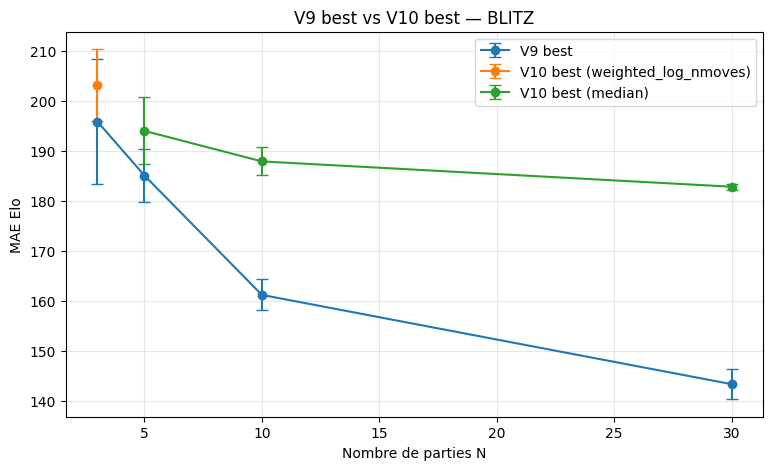

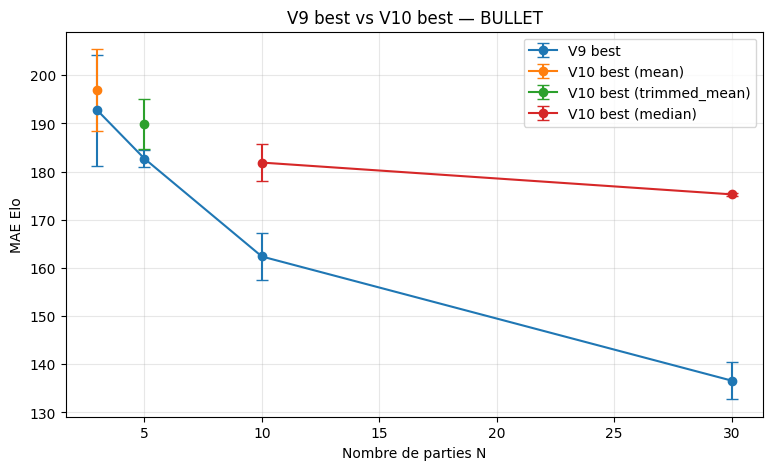

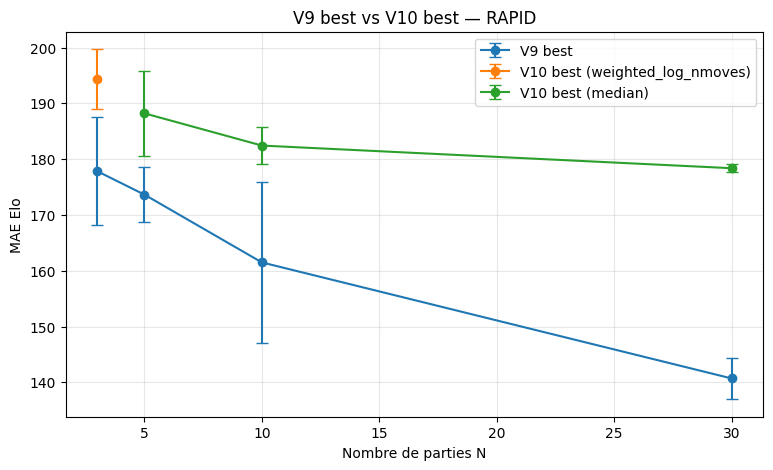

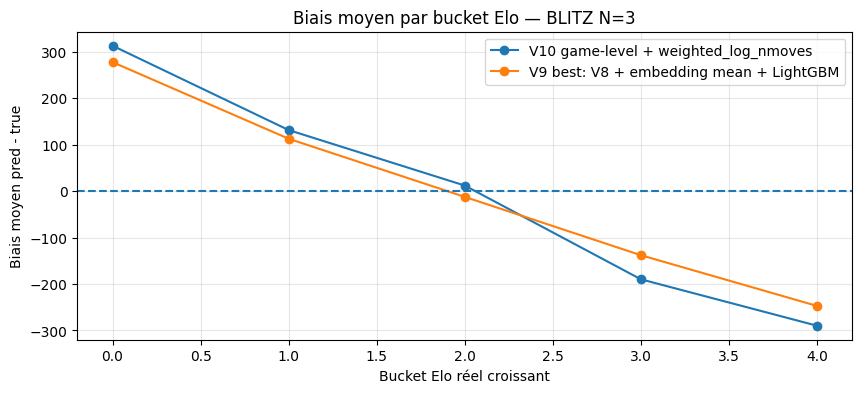

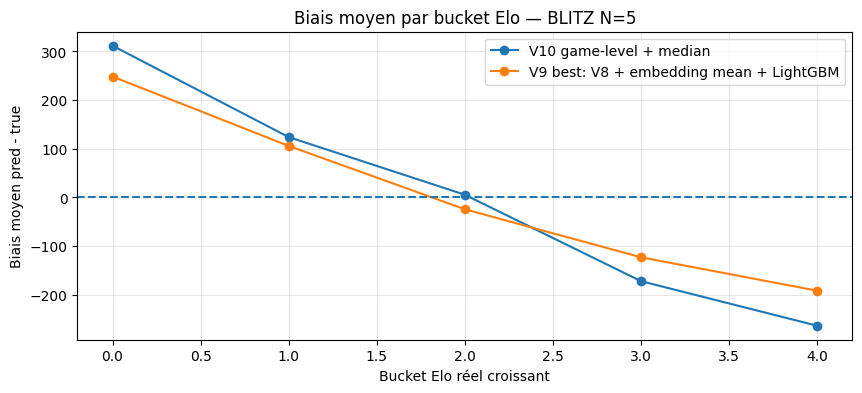

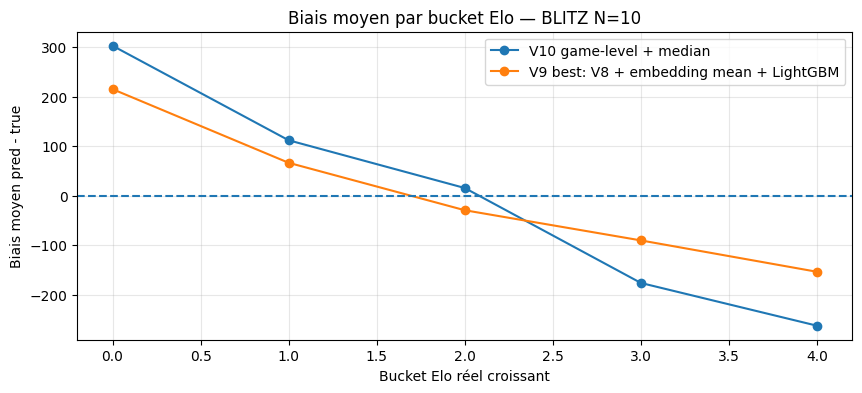

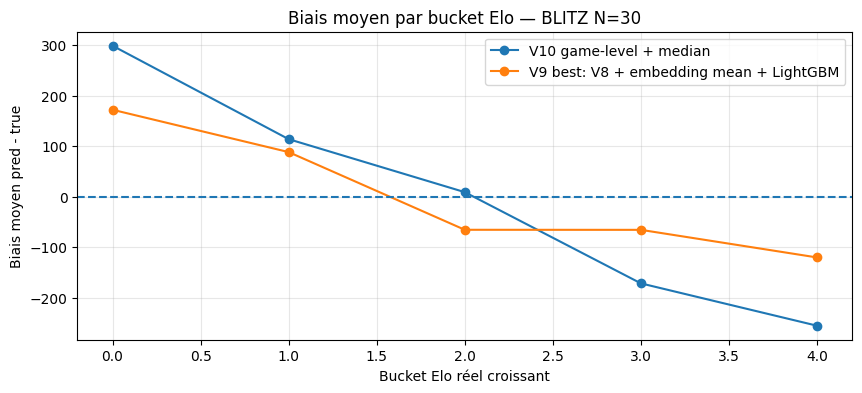

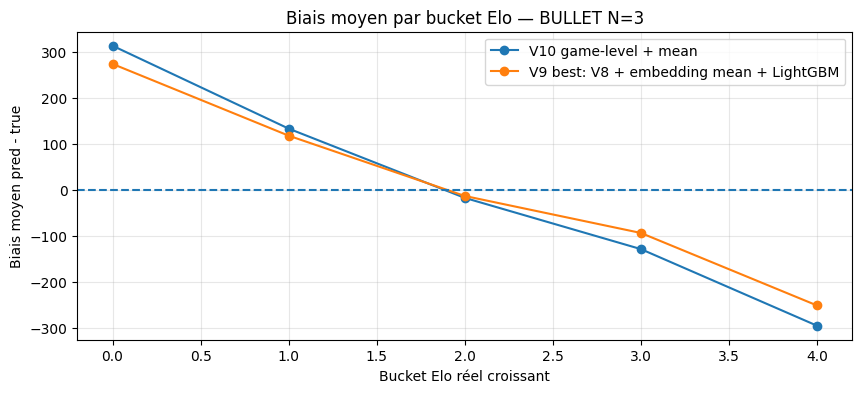

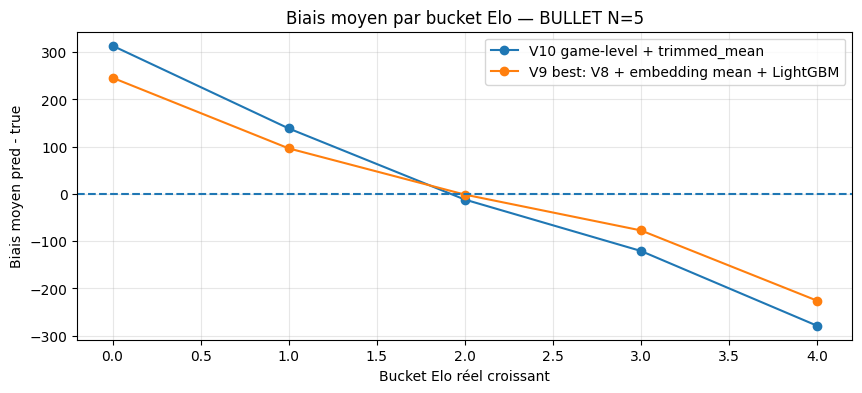

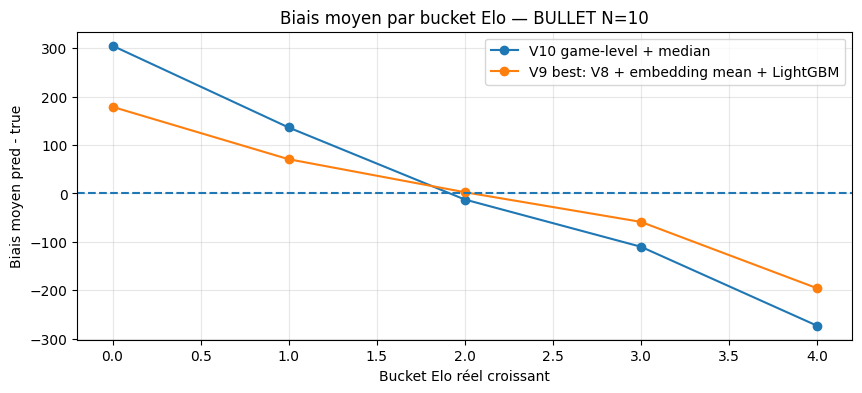

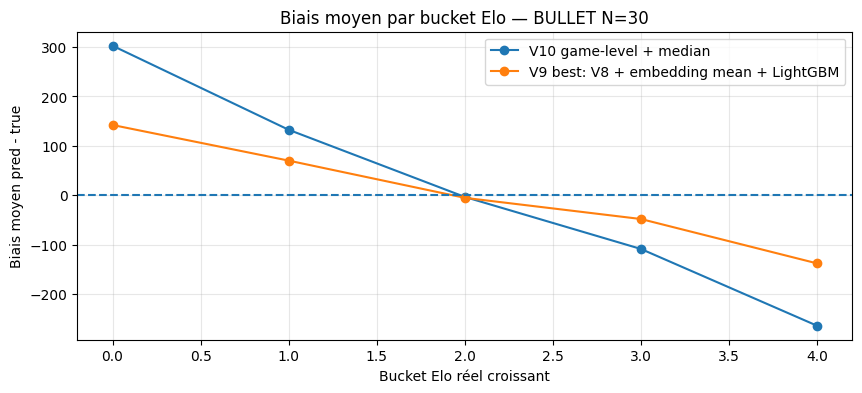

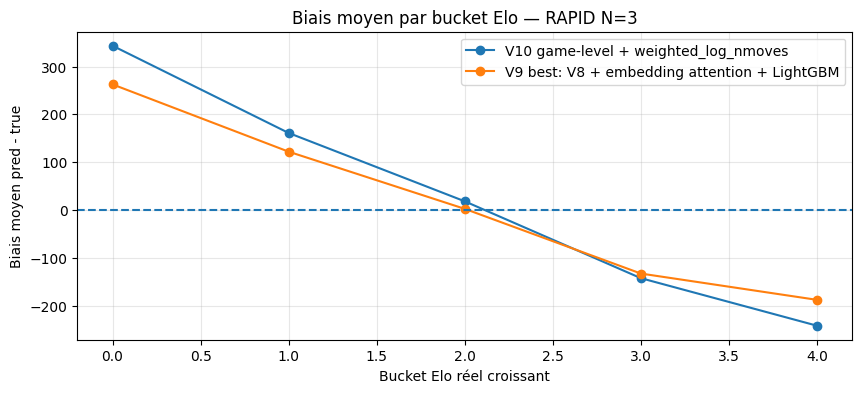

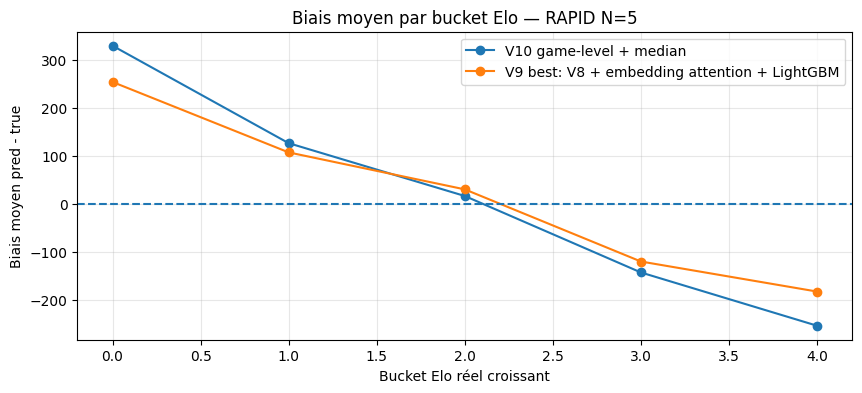

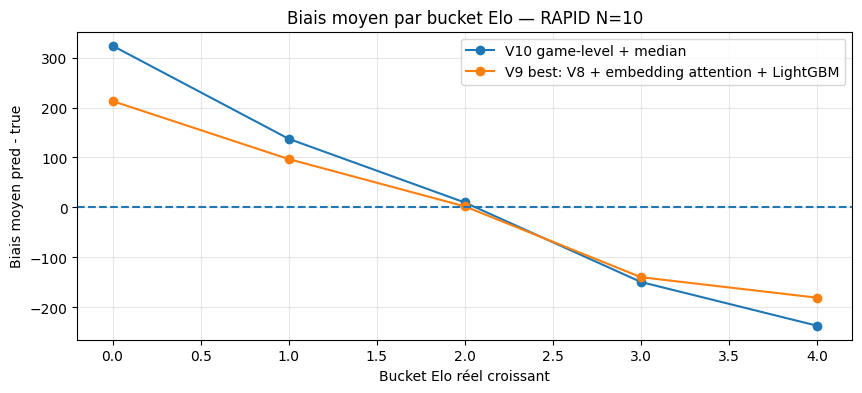

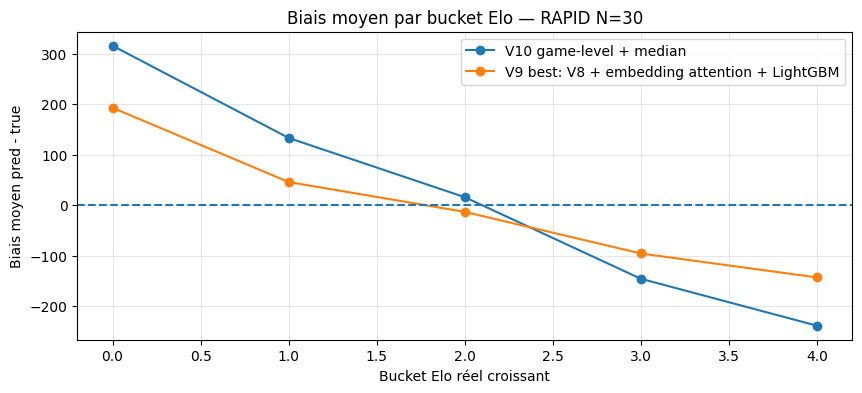

In [25]:
# ============================================================
# 17. Visualisations synthétiques
# ============================================================

# 1) MAE par cadence/N : V9 vs meilleur V10
best_v10_by_cadence_N = (
    v10_summary.sort_values(['cadence','N','MAE_mean'])
    .groupby(['cadence','N']).first().reset_index()
)
v9_plot = v9_best_summary.copy()
v9_plot['plot_label'] = 'V9 best'
best_v10_by_cadence_N['plot_label'] = best_v10_by_cadence_N['aggregator'].apply(lambda x: f'V10 best ({x})')
plot_df = pd.concat([
    v9_plot[['cadence','N','MAE_mean','MAE_std','plot_label']],
    best_v10_by_cadence_N[['cadence','N','MAE_mean','MAE_std','plot_label']]
], ignore_index=True)

for cadence in plot_df['cadence'].unique():
    sub = plot_df[plot_df['cadence'] == cadence].copy()
    plt.figure(figsize=(9, 5))
    for label in sub['plot_label'].unique():
        s = sub[sub['plot_label'] == label].sort_values('N')
        plt.errorbar(s['N'], s['MAE_mean'], yerr=s['MAE_std'], marker='o', capsize=4, label=label)
    plt.title(f'V9 best vs V10 best — {cadence.upper()}')
    plt.xlabel('Nombre de parties N')
    plt.ylabel('MAE Elo')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# 2) Biais par bucket Elo pour V9 et meilleur V10 uniquement.
if 'bucket_summary' in globals() and not bucket_summary.empty:
    for cadence in bucket_summary['cadence'].unique():
        for N in N_VALUES:
            sub_best_v10 = best_v10_by_cadence_N[(best_v10_by_cadence_N['cadence']==cadence) & (best_v10_by_cadence_N['N']==N)]
            if sub_best_v10.empty:
                continue
            best_agg = sub_best_v10.iloc[0]['aggregator']
            sub = bucket_summary[(bucket_summary['cadence']==cadence) & (bucket_summary['N']==N)]
            sub = sub[(sub['family']=='V9 embedding + LightGBM') | ((sub['family']=='V10 game-level hierarchical') & (sub['aggregator']==best_agg))]
            if sub.empty:
                continue
            plt.figure(figsize=(10, 4))
            for approach in sub['approach'].unique():
                s = sub[sub['approach']==approach].copy()
                x = np.arange(len(s))
                plt.plot(x, s['bias_mean'], marker='o', label=approach)
            plt.axhline(0, linestyle='--')
            plt.title(f'Biais moyen par bucket Elo — {cadence.upper()} N={N}')
            plt.xlabel('Bucket Elo réel croissant')
            plt.ylabel('Biais moyen pred - true')
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()


In [26]:
# ============================================================
# 18. Sauvegarde des résultats V10 corrigée vs V9 best
# ============================================================

SAVE_DIR = CACHE_DIR if 'CACHE_DIR' in globals() else Path('./_v10_cache')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

v9_best_df.to_csv(SAVE_DIR / 'v10_corrected_v9_best_by_seed.csv', index=False)
v10_results_df.to_csv(SAVE_DIR / 'v10_corrected_game_level_by_seed.csv', index=False)
comparison_v9_v10.to_csv(SAVE_DIR / 'v10_corrected_comparison_v9_v10.csv', index=False)
gain_vs_v9.to_csv(SAVE_DIR / 'v10_corrected_gain_vs_v9.csv', index=False)

if 'v10_uncertainty_summary' in globals():
    v10_uncertainty_summary.to_csv(SAVE_DIR / 'v10_corrected_uncertainty_summary.csv', index=False)
if 'dispersion_summary' in globals() and not dispersion_summary.empty:
    dispersion_summary.to_csv(SAVE_DIR / 'v10_corrected_dispersion_summary.csv', index=False)
if 'bucket_summary' in globals() and not bucket_summary.empty:
    bucket_summary.to_csv(SAVE_DIR / 'v10_corrected_bucket_bias_summary.csv', index=False)

print('Résultats sauvegardés dans :', SAVE_DIR)
print('Note méthodologique : si RETRAIN_V9_NEURAL_PER_SEED=True, la variance inclut une partie de la variabilité neural V9.')
print('Si vous mettez RETRAIN_V9_NEURAL_PER_SEED=False, les écarts-types reflètent surtout l’échantillonnage exact-N et LightGBM.')


Résultats sauvegardés dans : /content/_v10_cache
Note méthodologique : si RETRAIN_V9_NEURAL_PER_SEED=True, la variance inclut une partie de la variabilité neural V9.
Si vous mettez RETRAIN_V9_NEURAL_PER_SEED=False, les écarts-types reflètent surtout l’échantillonnage exact-N et LightGBM.


In [27]:
# ============================================================
# 19. Analyse de compression des prédictions V10
# ============================================================

# Objectif :
# Montrer si V10 ramène les prédictions vers une zone centrale.
#
# On analyse par bucket Elo réel :
# - Elo réel moyen
# - Elo prédit moyen
# - biais moyen = pred - true
# - MAE
#
# Si :
# - biais positif chez les faibles Elo  => surestimation
# - biais négatif chez les forts Elo    => sous-estimation
# alors le modèle compresse les extrêmes vers la moyenne.

def add_elo_buckets(df, y_col="elo", n_bins=5):
    df = df.copy()
    try:
        df["elo_bucket"] = pd.qcut(
            df[y_col],
            q=n_bins,
            labels=False,
            duplicates="drop"
        )
    except ValueError:
        df["elo_bucket"] = pd.cut(
            df[y_col],
            bins=n_bins,
            labels=False,
            duplicates="drop"
        )
    return df


compression_rows = []

for (cadence, N, seed), agg_tables in v10_prediction_tables.items():
    for agg, tables in agg_tables.items():
        test_df = tables["test"].copy()

        if "pred_player_elo" not in test_df.columns:
            print(f"⚠️ pred_player_elo absent pour {cadence}, N={N}, seed={seed}, agg={agg}")
            continue

        test_df = add_elo_buckets(test_df, y_col="elo", n_bins=5)

        test_df["bias"] = (
            test_df["pred_player_elo"].astype(float)
            - test_df["elo"].astype(float)
        )

        test_df["abs_error"] = np.abs(test_df["bias"])

        bucket_stats = (
            test_df
            .groupby("elo_bucket", observed=False)
            .agg(
                elo_true_mean=("elo", "mean"),
                elo_true_min=("elo", "min"),
                elo_true_max=("elo", "max"),
                pred_mean=("pred_player_elo", "mean"),
                bias_mean=("bias", "mean"),
                MAE=("abs_error", "mean"),
                n=("elo", "count")
            )
            .reset_index()
        )

        bucket_stats["cadence"] = cadence
        bucket_stats["N"] = N
        bucket_stats["seed"] = seed
        bucket_stats["aggregator"] = agg

        compression_rows.append(bucket_stats)


compression_detail_df = (
    pd.concat(compression_rows, ignore_index=True)
    if compression_rows
    else pd.DataFrame()
)

compression_summary = (
    compression_detail_df
    .groupby(["cadence", "N", "aggregator", "elo_bucket"], observed=False)
    .agg(
        elo_true_mean=("elo_true_mean", "mean"),
        elo_true_min=("elo_true_min", "mean"),
        elo_true_max=("elo_true_max", "mean"),
        pred_mean=("pred_mean", "mean"),
        bias_mean=("bias_mean", "mean"),
        MAE=("MAE", "mean"),
        n=("n", "sum")
    )
    .reset_index()
    .sort_values(["cadence", "N", "aggregator", "elo_bucket"])
)

display(compression_summary)

print("""
Lecture :
- bias_mean > 0 : le modèle surestime ce bucket.
- bias_mean < 0 : le modèle sous-estime ce bucket.
- Si les faibles Elo ont un biais positif et les forts Elo un biais négatif,
  alors V10 compresse les prédictions vers la moyenne.
""")

,cadence,N,aggregator,elo_bucket,elo_true_mean,elo_true_min,elo_true_max,pred_mean,bias_mean,MAE,n
0,blitz,3,mean,0,1247.321,991.500,1402.000,1558.296,310.974,311.998,140
1,blitz,3,mean,1,1505.464,1417.000,1591.500,1635.306,129.842,137.459,140
2,blitz,3,mean,2,1665.857,1602.000,1784.500,1676.391,10.534,80.218,140
3,blitz,3,mean,3,1893.607,1809.500,1964.000,1700.838,-192.769,196.418,140
4,blitz,3,mean,4,2062.536,2006.500,2190.500,1770.647,-291.889,291.889,140
...,...,...,...,...,...,...,...,...,...,...,...
235,rapid,30,weighted_log_nmoves,0,1154.650,1008.500,1305.500,1479.267,324.617,324.617,100
236,rapid,30,weighted_log_nmoves,1,1416.921,1319.500,1509.500,1552.973,136.052,138.670,95
237,rapid,30,weighted_log_nmoves,2,1571.500,1510.500,1666.000,1593.313,21.813,44.261,100
238,rapid,30,weighted_log_nmoves,3,1764.474,1668.500,1858.500,1623.606,-140.868,140.868,95



Lecture :
- bias_mean > 0 : le modèle surestime ce bucket.
- bias_mean < 0 : le modèle sous-estime ce bucket.
- Si les faibles Elo ont un biais positif et les forts Elo un biais négatif,
  alors V10 compresse les prédictions vers la moyenne.



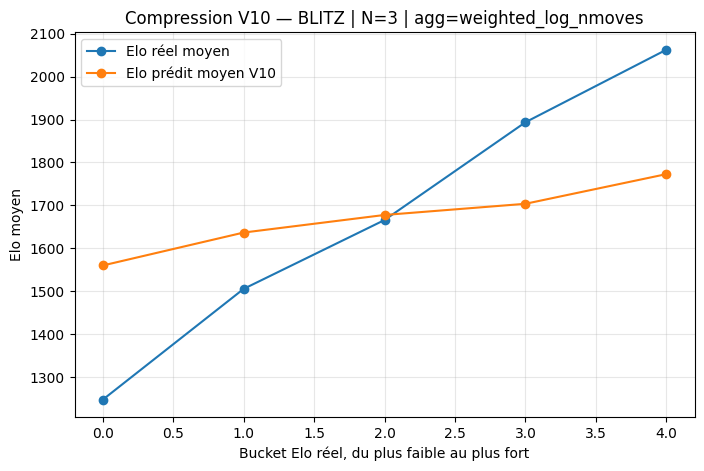

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
15,blitz,3,weighted_log_nmoves,0,1247.321,1559.976,312.654,313.773,140
16,blitz,3,weighted_log_nmoves,1,1505.464,1636.686,131.222,138.804,140
17,blitz,3,weighted_log_nmoves,2,1665.857,1677.649,11.792,79.714,140
18,blitz,3,weighted_log_nmoves,3,1893.607,1703.686,-189.921,193.585,140
19,blitz,3,weighted_log_nmoves,4,2062.536,1772.764,-289.771,289.771,140


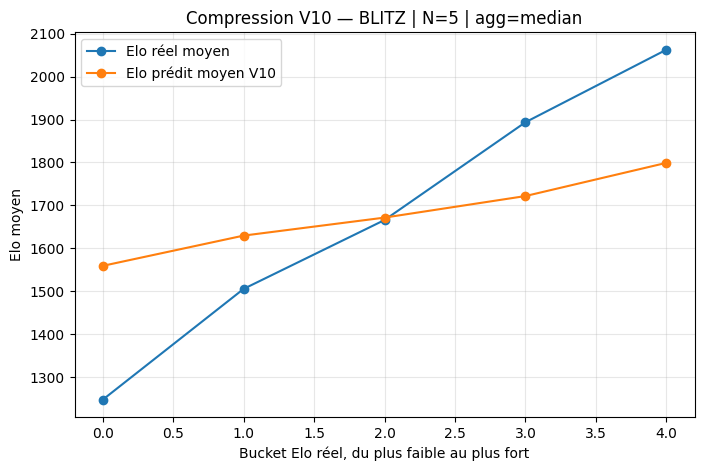

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
25,blitz,5,median,0,1247.321,1559.123,311.802,311.802,140
26,blitz,5,median,1,1505.464,1629.585,124.121,133.131,140
27,blitz,5,median,2,1665.857,1671.506,5.648,87.320,140
28,blitz,5,median,3,1893.607,1721.711,-171.896,174.030,140
29,blitz,5,median,4,2062.536,1799.007,-263.529,263.529,140


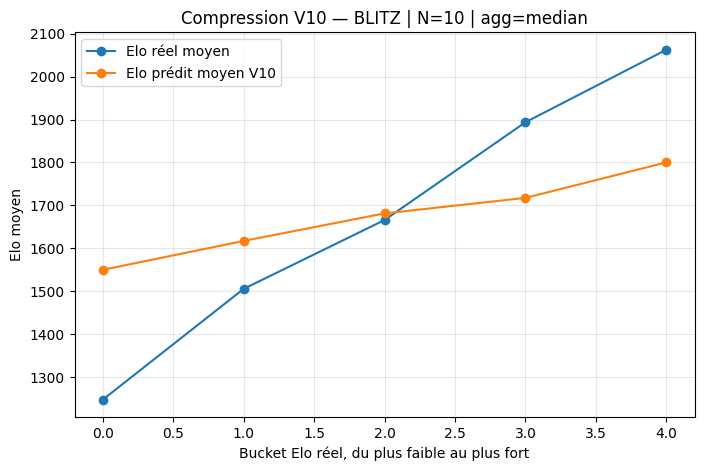

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
45,blitz,10,median,0,1247.321,1549.816,302.495,302.495,140
46,blitz,10,median,1,1505.464,1617.218,111.753,119.533,140
47,blitz,10,median,2,1665.857,1681.274,15.417,76.516,140
48,blitz,10,median,3,1893.607,1717.446,-176.161,178.324,140
49,blitz,10,median,4,2062.536,1800.120,-262.416,262.416,140


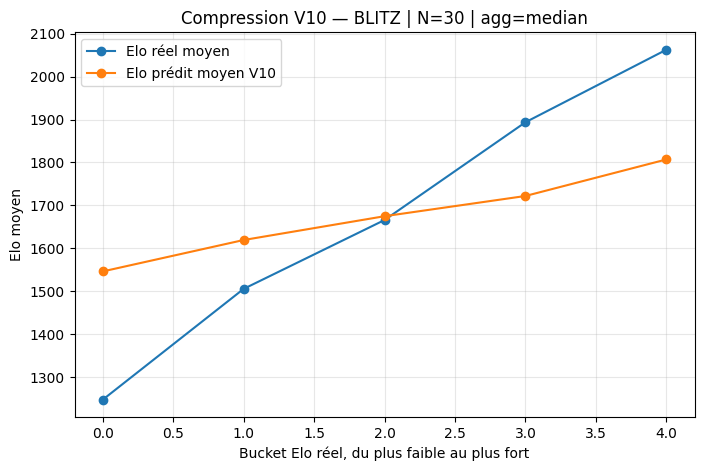

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
65,blitz,30,median,0,1247.321,1546.141,298.819,298.819,140
66,blitz,30,median,1,1505.464,1619.290,113.826,118.208,140
67,blitz,30,median,2,1665.857,1674.751,8.893,69.652,140
68,blitz,30,median,3,1893.607,1721.871,-171.736,171.736,140
69,blitz,30,median,4,2062.536,1806.964,-255.572,255.572,140


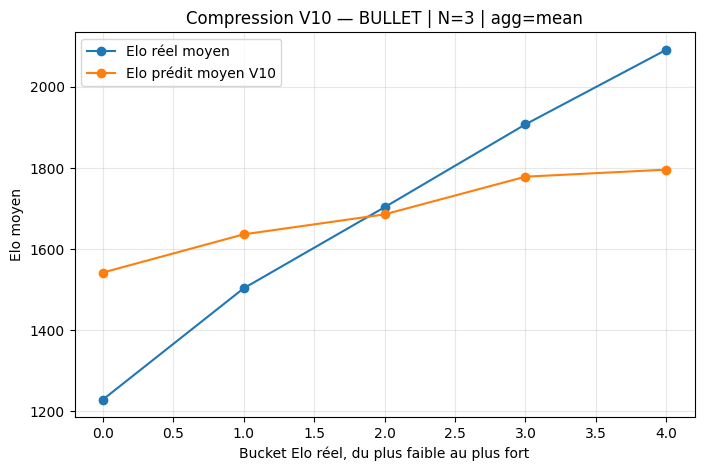

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
80,bullet,3,mean,0,1228.571,1542.022,313.451,314.873,140
81,bullet,3,mean,1,1503.161,1636.280,133.120,145.401,140
82,bullet,3,mean,2,1703.107,1685.548,-17.560,91.177,140
83,bullet,3,mean,3,1907.500,1778.494,-129.006,137.553,140
84,bullet,3,mean,4,2091.536,1795.870,-295.666,295.666,140


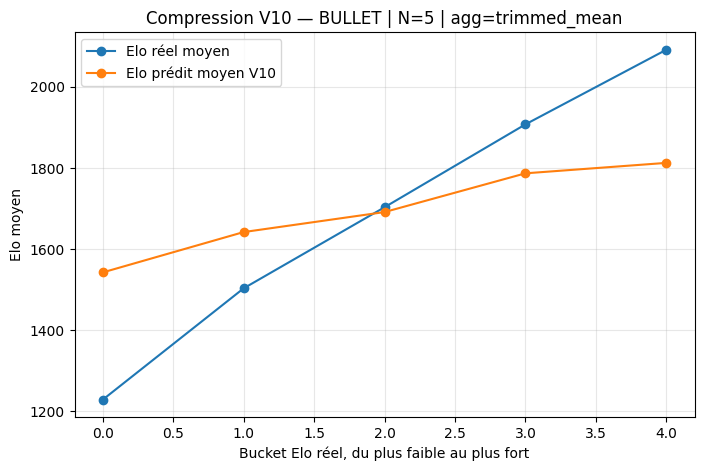

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
110,bullet,5,trimmed_mean,0,1228.571,1542.436,313.865,313.865,140
111,bullet,5,trimmed_mean,1,1503.161,1641.931,138.771,145.751,140
112,bullet,5,trimmed_mean,2,1703.107,1691.248,-11.860,86.488,140
113,bullet,5,trimmed_mean,3,1907.500,1786.785,-120.715,124.282,140
114,bullet,5,trimmed_mean,4,2091.536,1812.535,-279.001,279.001,140


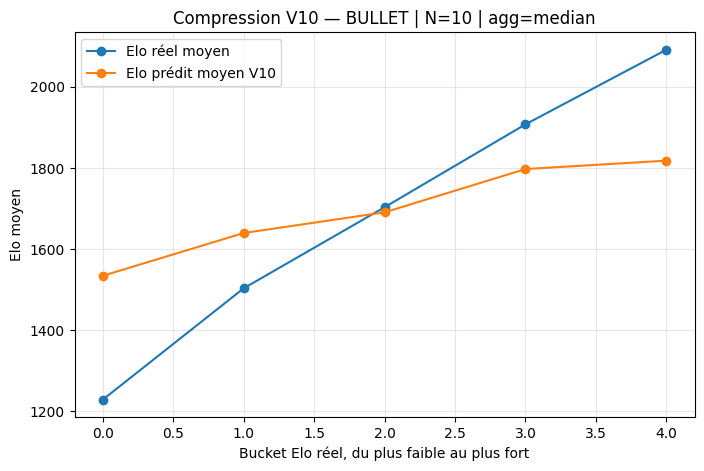

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
125,bullet,10,median,0,1228.571,1534.038,305.467,305.467,140
126,bullet,10,median,1,1503.161,1639.543,136.382,139.665,140
127,bullet,10,median,2,1703.107,1690.583,-12.524,76.422,140
128,bullet,10,median,3,1907.500,1797.278,-110.222,114.301,140
129,bullet,10,median,4,2091.536,1818.007,-273.529,273.529,140


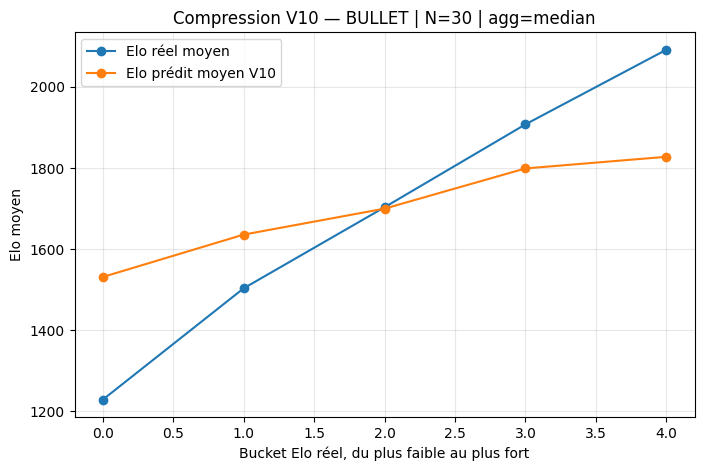

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
145,bullet,30,median,0,1228.571,1531.125,302.553,302.553,140
146,bullet,30,median,1,1503.161,1635.660,132.500,132.585,140
147,bullet,30,median,2,1703.107,1699.718,-3.389,66.387,140
148,bullet,30,median,3,1907.500,1798.836,-108.664,110.903,140
149,bullet,30,median,4,2091.536,1827.558,-263.977,263.977,140


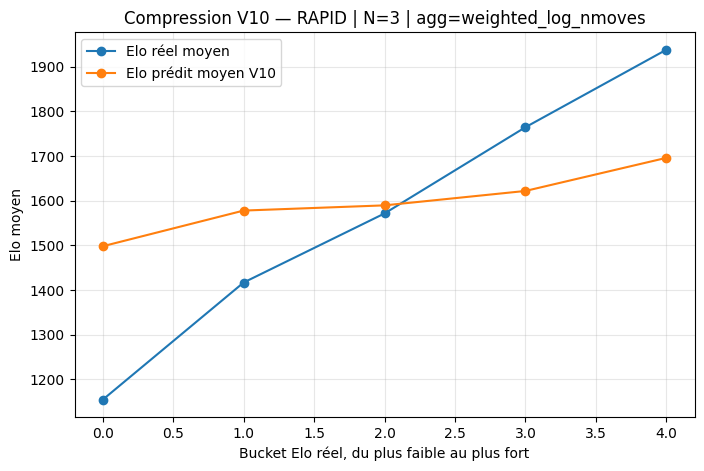

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
175,rapid,3,weighted_log_nmoves,0,1154.650,1498.096,343.446,343.446,100
176,rapid,3,weighted_log_nmoves,1,1416.921,1577.950,161.029,166.709,95
177,rapid,3,weighted_log_nmoves,2,1571.500,1589.605,18.105,69.899,100
178,rapid,3,weighted_log_nmoves,3,1764.474,1621.862,-142.611,145.913,95
179,rapid,3,weighted_log_nmoves,4,1937.925,1695.931,-241.994,241.994,100


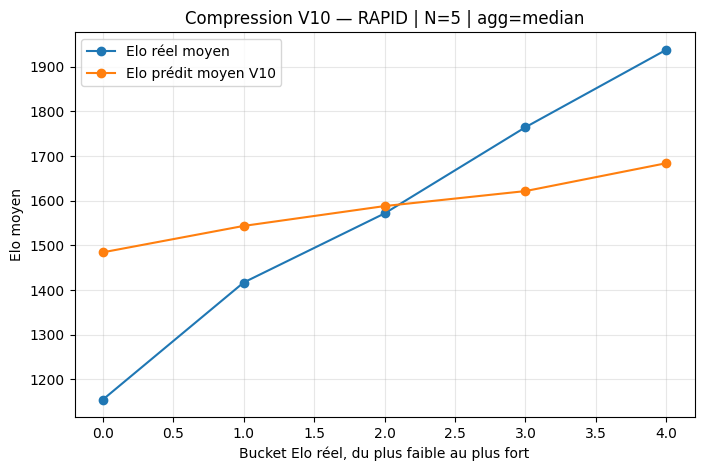

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
185,rapid,5,median,0,1154.650,1484.446,329.796,329.796,100
186,rapid,5,median,1,1416.921,1543.596,126.675,133.251,95
187,rapid,5,median,2,1571.500,1588.014,16.514,71.745,100
188,rapid,5,median,3,1764.474,1621.579,-142.895,147.530,95
189,rapid,5,median,4,1937.925,1683.995,-253.930,253.930,100


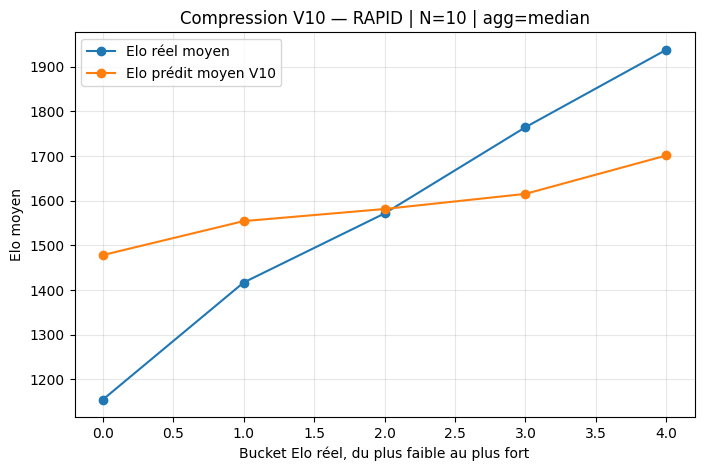

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
205,rapid,10,median,0,1154.650,1478.310,323.660,323.660,100
206,rapid,10,median,1,1416.921,1554.356,137.435,142.235,95
207,rapid,10,median,2,1571.500,1581.479,9.979,56.834,100
208,rapid,10,median,3,1764.474,1615.342,-149.132,149.132,95
209,rapid,10,median,4,1937.925,1701.291,-236.634,236.634,100


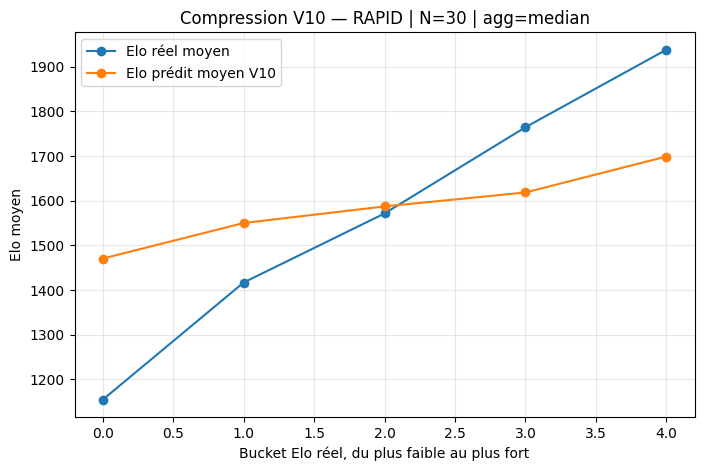

,cadence,N,aggregator,elo_bucket,elo_true_mean,pred_mean,bias_mean,MAE,n
225,rapid,30,median,0,1154.650,1470.580,315.930,315.930,100
226,rapid,30,median,1,1416.921,1550.114,133.193,136.399,95
227,rapid,30,median,2,1571.500,1587.245,15.745,50.832,100
228,rapid,30,median,3,1764.474,1618.487,-145.987,145.987,95
229,rapid,30,median,4,1937.925,1698.907,-239.018,239.018,100


In [28]:
# ============================================================
# 20. Visualisation : vraie moyenne vs prédite moyenne par bucket
# ============================================================

# On affiche uniquement le meilleur agrégateur V10 par cadence/N,
# pour éviter trop de figures.

if "v10_summary" not in globals():
    raise RuntimeError("v10_summary est absent. Exécute d'abord la cellule de résumé V10.")

best_v10_by_cadence_N = (
    v10_summary
    .sort_values(["cadence", "N", "MAE_mean"])
    .groupby(["cadence", "N"])
    .first()
    .reset_index()
)

for _, row in best_v10_by_cadence_N.iterrows():
    cadence = row["cadence"]
    N = row["N"]
    best_agg = row["aggregator"]

    sub = compression_summary[
        (compression_summary["cadence"] == cadence)
        & (compression_summary["N"] == N)
        & (compression_summary["aggregator"] == best_agg)
    ].copy()

    if sub.empty:
        continue

    plt.figure(figsize=(8, 5))

    plt.plot(
        sub["elo_bucket"],
        sub["elo_true_mean"],
        marker="o",
        label="Elo réel moyen"
    )

    plt.plot(
        sub["elo_bucket"],
        sub["pred_mean"],
        marker="o",
        label="Elo prédit moyen V10"
    )

    plt.title(f"Compression V10 — {cadence.upper()} | N={N} | agg={best_agg}")
    plt.xlabel("Bucket Elo réel, du plus faible au plus fort")
    plt.ylabel("Elo moyen")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    display(sub[[
        "cadence",
        "N",
        "aggregator",
        "elo_bucket",
        "elo_true_mean",
        "pred_mean",
        "bias_mean",
        "MAE",
        "n"
    ]])

In [29]:
# ============================================================
# 21. Calibration post-hoc de V10 sur validation
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics_local(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "bias": float(np.mean(y_pred - y_true)),
    }


def get_v10_calibration_features(df):
    """
    Crée les features utilisées pour calibrer V10.
    Robuste aux colonnes absentes.
    """
    df = df.copy()

    candidate_cols = [
        "pred_player_elo",
        "game_pred_std",
        "game_pred_iqr",
        "game_pred_range",
        "game_pred_min",
        "game_pred_max",
        "game_pred_mean",
        "n_games",
        "N",
    ]

    # Ajouter des colonnes dérivées utiles
    if "pred_player_elo" in df.columns:
        df["pred_centered"] = df["pred_player_elo"] - df["pred_player_elo"].mean()
        candidate_cols.append("pred_centered")

    if "game_pred_std" in df.columns and "pred_player_elo" in df.columns:
        df["std_x_pred"] = df["game_pred_std"] * df["pred_player_elo"]
        candidate_cols.append("std_x_pred")

    feature_cols = [c for c in candidate_cols if c in df.columns]

    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    return X, feature_cols


def calibrate_v10_one(val_df, test_df, method="ridge"):
    """
    Calibre les prédictions V10 sur validation puis applique sur test.

    method='ridge' : calibration linéaire stable.
    method='rf'    : calibration non linéaire, plus risquée.
    """
    val_df = val_df.copy()
    test_df = test_df.copy()

    X_val, feature_cols = get_v10_calibration_features(val_df)
    X_test, _ = get_v10_calibration_features(test_df)

    # Aligner les colonnes au cas où
    X_test = X_test.reindex(columns=feature_cols, fill_value=0)

    y_val = val_df["elo"].astype(float).values

    if method == "ridge":
        calibrator = Ridge(alpha=10.0)
    elif method == "rf":
        calibrator = RandomForestRegressor(
            n_estimators=200,
            max_depth=3,
            random_state=0,
            n_jobs=-1
        )
    else:
        raise ValueError(f"Unknown method: {method}")

    calibrator.fit(X_val, y_val)

    pred_calibrated = calibrator.predict(X_test)

    return pred_calibrated, calibrator, feature_cols


v10_calibration_rows = []
v10_calibrated_predictions = {}
v10_calibrators = {}

CALIBRATION_METHODS = ["ridge"]  # garde simple. Tu peux ajouter "rf" après.

for (cadence, N, seed), agg_tables in v10_prediction_tables.items():
    for agg, tables in agg_tables.items():
        val_df = tables["val"].copy()
        test_df = tables["test"].copy()

        # Sécurité : ajouter N comme feature explicite
        val_df["N"] = N
        test_df["N"] = N

        y_test = test_df["elo"].astype(float).values
        pred_raw = test_df["pred_player_elo"].astype(float).values

        raw_metrics = regression_metrics_local(y_test, pred_raw)

        for method in CALIBRATION_METHODS:
            pred_calib, calibrator, calib_feature_cols = calibrate_v10_one(
                val_df,
                test_df,
                method=method
            )

            calib_metrics = regression_metrics_local(y_test, pred_calib)

            row = {
                "cadence": cadence,
                "N": N,
                "seed": seed,
                "aggregator": agg,
                "calibration": method,

                "MAE_raw": raw_metrics["MAE"],
                "RMSE_raw": raw_metrics["RMSE"],
                "R2_raw": raw_metrics["R2"],
                "bias_raw": raw_metrics["bias"],

                "MAE_calibrated": calib_metrics["MAE"],
                "RMSE_calibrated": calib_metrics["RMSE"],
                "R2_calibrated": calib_metrics["R2"],
                "bias_calibrated": calib_metrics["bias"],

                "gain_MAE_calibration": raw_metrics["MAE"] - calib_metrics["MAE"],
                "n_test": len(test_df),
                "n_calib_features": len(calib_feature_cols),
            }

            v10_calibration_rows.append(row)

            key = (cadence, N, seed, agg, method)
            v10_calibrators[key] = {
                "calibrator": calibrator,
                "feature_cols": calib_feature_cols,
            }

            pred_table = test_df.copy()
            pred_table["pred_v10_raw"] = pred_raw
            pred_table["pred_v10_calibrated"] = pred_calib
            pred_table["abs_error_raw"] = np.abs(pred_table["elo"] - pred_table["pred_v10_raw"])
            pred_table["abs_error_calibrated"] = np.abs(pred_table["elo"] - pred_table["pred_v10_calibrated"])

            v10_calibrated_predictions[key] = pred_table


v10_calibration_df = pd.DataFrame(v10_calibration_rows)

v10_calibration_summary = (
    v10_calibration_df
    .groupby(["cadence", "N", "aggregator", "calibration"])
    .agg(
        MAE_raw=("MAE_raw", "mean"),
        MAE_raw_std=("MAE_raw", "std"),
        MAE_calibrated=("MAE_calibrated", "mean"),
        MAE_calibrated_std=("MAE_calibrated", "std"),
        gain_MAE_calibration=("gain_MAE_calibration", "mean"),
        R2_raw=("R2_raw", "mean"),
        R2_calibrated=("R2_calibrated", "mean"),
        bias_raw=("bias_raw", "mean"),
        bias_calibrated=("bias_calibrated", "mean"),
        n_runs=("seed", "count")
    )
    .reset_index()
    .sort_values(["cadence", "N", "MAE_calibrated"])
)

display(v10_calibration_summary)

print("""
Lecture :
- gain_MAE_calibration > 0 : la calibration améliore V10.
- bias_calibrated proche de 0 : la calibration corrige le biais global.
- Si la MAE baisse surtout dans les buckets extrêmes, la calibration réduit la compression.
""")

,cadence,N,aggregator,calibration,MAE_raw,MAE_raw_std,MAE_calibrated,MAE_calibrated_std,gain_MAE_calibration,R2_raw,R2_calibrated,bias_raw,bias_calibrated,n_runs
3,blitz,3,weighted_log_nmoves,ridge,203.130,7.152,196.391,11.793,6.738,0.317,0.321,-4.805,-3.141,5
0,blitz,3,mean,ridge,203.596,7.594,196.484,12.189,7.112,0.314,0.325,-6.662,-8.229,5
2,blitz,3,trimmed_mean,ridge,203.596,7.594,196.484,12.189,7.112,0.314,0.325,-6.662,-8.229,5
1,blitz,3,median,ridge,204.750,10.365,198.113,11.413,6.636,0.303,0.316,-5.202,-5.994,5
5,blitz,5,median,ridge,193.962,6.721,180.207,9.924,13.756,0.384,0.427,1.229,5.114,5
4,blitz,5,mean,ridge,196.408,3.951,180.711,10.373,15.697,0.377,0.425,-0.390,3.238,5
6,blitz,5,trimmed_mean,ridge,194.623,6.356,180.898,10.390,13.726,0.385,0.424,0.725,4.510,5
7,blitz,5,weighted_log_nmoves,ridge,196.535,4.018,185.671,10.559,10.864,0.376,0.382,1.565,-12.850,5
11,blitz,10,weighted_log_nmoves,ridge,188.110,2.677,165.017,6.934,23.093,0.429,0.537,-3.747,-1.067,5
9,blitz,10,median,ridge,187.857,2.813,165.956,6.304,21.900,0.431,0.529,-1.782,2.051,5



Lecture :
- gain_MAE_calibration > 0 : la calibration améliore V10.
- bias_calibrated proche de 0 : la calibration corrige le biais global.
- Si la MAE baisse surtout dans les buckets extrêmes, la calibration réduit la compression.



In [30]:
# ============================================================
# 22. Comparaison finale : V9 best vs V10 brut vs V10 calibré
# ============================================================

# Référence V9 par cadence/N
if "v9_best_df" not in globals():
    raise RuntimeError("v9_best_df absent. Exécute d'abord l'expérience V9/V10.")

v9_ref_summary = (
    v9_best_df
    .groupby(["cadence", "N"])
    .agg(
        MAE_V9=("MAE", "mean"),
        MAE_V9_std=("MAE", "std"),
        R2_V9=("R2", "mean"),
        n_runs_V9=("seed", "count")
    )
    .reset_index()
)

# Meilleur V10 calibré par cadence/N
best_v10_calib = (
    v10_calibration_summary
    .sort_values(["cadence", "N", "MAE_calibrated"])
    .groupby(["cadence", "N"])
    .first()
    .reset_index()
)

final_calib_comparison = best_v10_calib.merge(
    v9_ref_summary,
    on=["cadence", "N"],
    how="left"
)

final_calib_comparison["gain_V10_calibrated_vs_V9"] = (
    final_calib_comparison["MAE_V9"]
    - final_calib_comparison["MAE_calibrated"]
)

final_calib_comparison["gain_V10_raw_vs_V9"] = (
    final_calib_comparison["MAE_V9"]
    - final_calib_comparison["MAE_raw"]
)

final_calib_comparison["MAE_V9_display"] = (
    final_calib_comparison["MAE_V9"].round(1).astype(str)
    + " ± "
    + final_calib_comparison["MAE_V9_std"].round(1).astype(str)
)

final_calib_comparison["MAE_raw_display"] = (
    final_calib_comparison["MAE_raw"].round(1).astype(str)
    + " ± "
    + final_calib_comparison["MAE_raw_std"].round(1).astype(str)
)

final_calib_comparison["MAE_calibrated_display"] = (
    final_calib_comparison["MAE_calibrated"].round(1).astype(str)
    + " ± "
    + final_calib_comparison["MAE_calibrated_std"].round(1).astype(str)
)

display(final_calib_comparison[[
    "cadence",
    "N",
    "aggregator",
    "calibration",
    "MAE_V9_display",
    "MAE_raw_display",
    "MAE_calibrated_display",
    "gain_MAE_calibration",
    "gain_V10_raw_vs_V9",
    "gain_V10_calibrated_vs_V9",
    "bias_raw",
    "bias_calibrated",
    "R2_V9",
    "R2_raw",
    "R2_calibrated",
    "n_runs"
]])

print("""
Lecture :
- gain_MAE_calibration > 0 : calibration améliore V10.
- gain_V10_calibrated_vs_V9 > 0 : V10 calibré bat V9.
- Si V10 calibré reste inférieur à V9, on garde V9 comme modèle final,
  mais on peut discuter la calibration comme amélioration partielle de V10.
""")

,cadence,N,aggregator,calibration,MAE_V9_display,MAE_raw_display,MAE_calibrated_display,gain_MAE_calibration,gain_V10_raw_vs_V9,gain_V10_calibrated_vs_V9,bias_raw,bias_calibrated,R2_V9,R2_raw,R2_calibrated,n_runs
0,blitz,3,weighted_log_nmoves,ridge,195.8 ± 12.6,203.1 ± 7.2,196.4 ± 11.8,6.738,-7.326,-0.587,-4.805,-3.141,0.323,0.317,0.321,5
1,blitz,5,median,ridge,185.0 ± 5.3,194.0 ± 6.7,180.2 ± 9.9,13.756,-8.929,4.827,1.229,5.114,0.367,0.384,0.427,5
2,blitz,10,weighted_log_nmoves,ridge,161.2 ± 3.1,188.1 ± 2.7,165.0 ± 6.9,23.093,-26.937,-3.843,-3.747,-1.067,0.515,0.429,0.537,5
3,blitz,30,weighted_log_nmoves,ridge,143.3 ± 3.0,184.1 ± 0.2,147.1 ± 1.7,36.999,-40.769,-3.770,-2.099,-28.413,0.610,0.455,0.635,5
4,bullet,3,mean,ridge,192.7 ± 11.5,196.9 ± 8.5,191.6 ± 13.4,5.365,-4.242,1.123,0.868,-2.859,0.355,0.381,0.387,5
5,bullet,5,mean,ridge,182.7 ± 1.8,191.7 ± 4.1,174.6 ± 6.8,17.090,-8.954,8.136,2.312,-16.100,0.426,0.430,0.476,5
6,bullet,10,mean,ridge,162.4 ± 4.8,183.2 ± 4.1,154.7 ± 8.4,28.546,-20.869,7.677,2.632,-4.657,0.551,0.469,0.574,5
7,bullet,30,weighted_log_nmoves,ridge,136.6 ± 3.9,179.4 ± 0.2,139.6 ± 1.3,39.772,-42.776,-3.004,6.144,-41.870,0.675,0.495,0.654,5
8,rapid,3,mean,ridge,177.8 ± 9.7,195.0 ± 5.0,183.9 ± 2.6,11.068,-17.159,-6.091,25.707,25.473,0.379,0.299,0.334,5
9,rapid,5,trimmed_mean,ridge,173.6 ± 5.0,189.6 ± 7.3,178.3 ± 18.1,11.276,-15.946,-4.670,17.913,27.319,0.433,0.351,0.371,5



Lecture :
- gain_MAE_calibration > 0 : calibration améliore V10.
- gain_V10_calibrated_vs_V9 > 0 : V10 calibré bat V9.
- Si V10 calibré reste inférieur à V9, on garde V9 comme modèle final,
  mais on peut discuter la calibration comme amélioration partielle de V10.



In [31]:
# ============================================================
# 23. Analyse par bucket après calibration : V10 brut vs V10 calibré
# ============================================================

# Objectif :
# Vérifier si la calibration réduit la compression des extrêmes.
#
# On compare par bucket Elo réel :
# - biais brut       = pred_v10_raw - elo
# - biais calibré   = pred_v10_calibrated - elo
# - MAE brute
# - MAE calibrée
#
# Si la calibration marche bien :
# - le biais positif des faibles Elo doit diminuer ;
# - le biais négatif des forts Elo doit se rapprocher de 0 ;
# - la MAE des buckets extrêmes doit baisser.

def add_elo_buckets_for_calibration(df, y_col="elo", n_bins=5):
    df = df.copy()
    try:
        df["elo_bucket"] = pd.qcut(
            df[y_col],
            q=n_bins,
            labels=False,
            duplicates="drop"
        )
    except ValueError:
        df["elo_bucket"] = pd.cut(
            df[y_col],
            bins=n_bins,
            labels=False,
            duplicates="drop"
        )
    return df


calibration_bucket_rows = []

for key, df_pred in v10_calibrated_predictions.items():
    cadence, N, seed, agg, method = key

    df = df_pred.copy()

    required_cols = ["elo", "pred_v10_raw", "pred_v10_calibrated"]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        print(f"⚠️ Colonnes manquantes pour {key} : {missing_cols}")
        continue

    df = add_elo_buckets_for_calibration(df, y_col="elo", n_bins=5)

    df["bias_raw"] = (
        df["pred_v10_raw"].astype(float)
        - df["elo"].astype(float)
    )

    df["bias_calibrated"] = (
        df["pred_v10_calibrated"].astype(float)
        - df["elo"].astype(float)
    )

    df["abs_error_raw"] = np.abs(df["bias_raw"])
    df["abs_error_calibrated"] = np.abs(df["bias_calibrated"])

    bucket_stats = (
        df
        .groupby("elo_bucket", observed=False)
        .agg(
            elo_true_mean=("elo", "mean"),
            elo_true_min=("elo", "min"),
            elo_true_max=("elo", "max"),

            pred_raw_mean=("pred_v10_raw", "mean"),
            pred_calibrated_mean=("pred_v10_calibrated", "mean"),

            bias_raw_mean=("bias_raw", "mean"),
            bias_calibrated_mean=("bias_calibrated", "mean"),

            MAE_raw=("abs_error_raw", "mean"),
            MAE_calibrated=("abs_error_calibrated", "mean"),

            n=("elo", "count")
        )
        .reset_index()
    )

    bucket_stats["cadence"] = cadence
    bucket_stats["N"] = N
    bucket_stats["seed"] = seed
    bucket_stats["aggregator"] = agg
    bucket_stats["calibration"] = method

    calibration_bucket_rows.append(bucket_stats)


calibration_bucket_detail_df = (
    pd.concat(calibration_bucket_rows, ignore_index=True)
    if calibration_bucket_rows
    else pd.DataFrame()
)

calibration_bucket_summary = (
    calibration_bucket_detail_df
    .groupby(
        ["cadence", "N", "aggregator", "calibration", "elo_bucket"],
        observed=False
    )
    .agg(
        elo_true_mean=("elo_true_mean", "mean"),
        elo_true_min=("elo_true_min", "mean"),
        elo_true_max=("elo_true_max", "mean"),

        pred_raw_mean=("pred_raw_mean", "mean"),
        pred_calibrated_mean=("pred_calibrated_mean", "mean"),

        bias_raw_mean=("bias_raw_mean", "mean"),
        bias_calibrated_mean=("bias_calibrated_mean", "mean"),

        MAE_raw=("MAE_raw", "mean"),
        MAE_calibrated=("MAE_calibrated", "mean"),

        n=("n", "sum")
    )
    .reset_index()
)

calibration_bucket_summary["bias_reduction_abs"] = (
    calibration_bucket_summary["bias_raw_mean"].abs()
    - calibration_bucket_summary["bias_calibrated_mean"].abs()
)

calibration_bucket_summary["MAE_gain_calibration"] = (
    calibration_bucket_summary["MAE_raw"]
    - calibration_bucket_summary["MAE_calibrated"]
)

calibration_bucket_summary = calibration_bucket_summary.sort_values(
    ["cadence", "N", "aggregator", "elo_bucket"]
)

display(calibration_bucket_summary)

print("""
Lecture :
- bias_raw_mean : biais de V10 brut dans le bucket.
- bias_calibrated_mean : biais après calibration.
- bias_reduction_abs > 0 : la calibration réduit le biais en valeur absolue.
- MAE_gain_calibration > 0 : la calibration améliore la MAE du bucket.

Ce qu'on veut voir :
- faibles Elo : biais positif brut réduit après calibration ;
- forts Elo : biais négatif brut moins négatif après calibration ;
- buckets extrêmes : MAE_calibrated < MAE_raw.
""")

,cadence,N,aggregator,calibration,elo_bucket,elo_true_mean,elo_true_min,elo_true_max,pred_raw_mean,pred_calibrated_mean,bias_raw_mean,bias_calibrated_mean,MAE_raw,MAE_calibrated,n,bias_reduction_abs,MAE_gain_calibration
0,blitz,3,mean,ridge,0,1247.321,991.500,1402.000,1558.296,1486.084,310.974,238.763,311.998,256.965,140,72.211,55.033
1,blitz,3,mean,ridge,1,1505.464,1417.000,1591.500,1635.306,1615.541,129.842,110.077,137.459,153.219,140,19.765,-15.760
2,blitz,3,mean,ridge,2,1665.857,1602.000,1784.500,1676.391,1680.479,10.534,14.622,80.218,124.796,140,-4.089,-44.579
3,blitz,3,mean,ridge,3,1893.607,1809.500,1964.000,1700.838,1718.527,-192.769,-175.080,196.418,204.659,140,17.689,-8.241
4,blitz,3,mean,ridge,4,2062.536,2006.500,2190.500,1770.647,1833.009,-291.889,-229.527,291.889,242.780,140,62.361,49.108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,rapid,30,weighted_log_nmoves,ridge,0,1154.650,1008.500,1305.500,1479.267,1338.288,324.617,183.638,324.617,183.910,100,140.979,140.707
236,rapid,30,weighted_log_nmoves,ridge,1,1416.921,1319.500,1509.500,1552.973,1494.154,136.052,77.233,138.670,123.200,95,58.819,15.471
237,rapid,30,weighted_log_nmoves,ridge,2,1571.500,1510.500,1666.000,1593.313,1597.575,21.813,26.075,44.261,90.470,100,-4.262,-46.209
238,rapid,30,weighted_log_nmoves,ridge,3,1764.474,1668.500,1858.500,1623.606,1653.611,-140.868,-110.863,140.868,136.819,95,30.006,4.049



Lecture :
- bias_raw_mean : biais de V10 brut dans le bucket.
- bias_calibrated_mean : biais après calibration.
- bias_reduction_abs > 0 : la calibration réduit le biais en valeur absolue.
- MAE_gain_calibration > 0 : la calibration améliore la MAE du bucket.

Ce qu'on veut voir :
- faibles Elo : biais positif brut réduit après calibration ;
- forts Elo : biais négatif brut moins négatif après calibration ;
- buckets extrêmes : MAE_calibrated < MAE_raw.




## Comment lire cette V10 corrigée

Cette version répond directement à la remarque méthodologique : **V10 est comparée à la meilleure baseline V9**, pas seulement à V8.

Les questions à regarder sont :

1. **Performance ponctuelle** : est-ce que V10 game-level bat ou approche V9 best ?
2. **Interprétabilité** : est-ce que les prédictions par partie montrent des profils stables/instables ?
3. **Incertitude** : est-ce que l’intervalle adaptatif basé sur `pred_std` réduit la largeur par rapport au conformal global ?

Même si V10 ne bat pas V9 en MAE, elle peut être utile si la dispersion des prédictions par partie est corrélée aux erreurs ou permet des intervalles plus personnalisés.